In [63]:
# =========================================================
# IMPORT LIBRARY
# =========================================================
import atoti as tt
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

In [64]:
# =========================================================
# MEMBACA DATA CSV
# =========================================================
df = pd.read_csv(r"C:\Users\Cut Azzahra\Downloads\Project DWH Fx\items\transformed\opensky_transformed.csv")

# =========================================================
# CEK DATASET
# =========================================================
print(df.head())

print("\nINFO DATASET")
print(df.info())

print("\nUKURAN DATASET")
print(df.shape)

   icao24 callsign origin_country  time_position   longitude   latitude  \
0  aa55b5  SKMX765  United States   1.672506e+09 -104.717921  38.699005   
1  a3bda6  DAL2614  United States   1.672506e+09  -83.624080  43.302812   
2  4bb294   TKJ206         Turkey   1.672506e+09   31.053197  33.181143   
3  ab4372   N825AD  United States   1.672506e+09 -115.437104  34.032720   
4  a05c45   N122MT  United States   1.672506e+09  -88.450857  35.412288   

   baro_altitude  on_ground    velocity  vertical_rate  ... month_name day  \
0       0.000000       True    6.869601           0.00  ...   December  31   
1    9458.028728      False  263.154919           0.33  ...   December  31   
2   10919.313610      False  189.770819          -0.33  ...   December  31   
3    8570.049922      False  134.226993           0.00  ...   December  31   
4    2693.083730      False   86.657933          -0.33  ...   December  31   

  hour day_of_week quarter  is_weekend  time_of_day flight_phase  \
0   16    Sa

In [65]:
# =========================================================
# UBAH DIMENSI NUMERIK JADI STRING
# =========================================================
df["year"] = df["year"].astype(str)
df["quarter"] = df["quarter"].astype(str)
df["day"] = df["day"].astype(str)
df["hour"] = df["hour"].astype(str)
df["month"] = df["month"].astype(str)

# =========================================================
# UBAH BOOLEAN KE INTEGER
# =========================================================
df["on_ground_numeric"] = df["on_ground"].astype(int)

In [66]:
# =========================================================
# MEMBUAT SESSION ATOTI
# =========================================================
session = tt.Session.start()
print("Session Atoti berhasil dibuat")

Session Atoti berhasil dibuat


In [67]:
# =========================================================
# MEMBUAT TABLE
# =========================================================
table = session.read_pandas(
    df,
    table_name="opensky_flight",
    keys=["icao24"]
)

print("Table berhasil dibuat")

# =========================================================
# MELIHAT STRUKTUR TABLE
# =========================================================
print(table)
table.head()


Table berhasil dibuat


,callsign,origin_country,time_position,longitude,latitude,baro_altitude,on_ground,velocity,vertical_rate,scraped_at,...,day,hour,day_of_week,quarter,is_weekend,time_of_day,flight_phase,region,continent,on_ground_numeric
icao24,,,,,,,,,,,,,,,,,,,,,
a3534a,EDV4918,United States,1760914826.248697,-81.597856,38.448474,8659.335697,False,218.369008,-4.88,2025-10-20 06:00:00,...,19,23,Sunday,4,True,Evening,Descent,North America,Americas,0
a92171,FDX1209,United States,1761497988.210304,-82.545719,28.539213,10470.242101,False,189.462229,11.05,2025-10-27 00:00:00,...,26,16,Sunday,4,True,Afternoon,Climb,North America,Americas,0
7c3616,UNKNOWN,Australia,1762513141.56476,145.121025,-37.96367,0.0,True,6.625466,0.0,2025-11-07 18:00:00,...,7,10,Friday,4,False,Morning,Ground,Oceania,Oceania,1
899094,EVA062,Taiwan,1762858838.573402,101.518743,13.765313,6356.026225,False,223.304107,6.5,2025-11-11 18:00:00,...,11,11,Tuesday,4,False,Morning,Climb,Southeast Asia,Asia,0
abe579,DAL2935,United States,1762945249.785924,-93.183295,44.815237,0.0,True,-8.065866,0.0,2025-11-12 18:00:00,...,12,11,Wednesday,4,False,Morning,Ground,North America,Americas,1


In [68]:
# =========================================================
# MEMBUAT CUBE
# =========================================================
cube = session.create_cube(table)

print("Cube berhasil dibuat")

Cube berhasil dibuat


In [69]:
# =========================================================
# HIERARCHY / DIMENSION
# =========================================================

# =========================================================
# DEFINISI HIERARCHY & LEVEL
# =========================================================
h = cube.hierarchies
l = cube.levels
m = cube.measures

# =========================
# TIME HIERARCHY
# =========================
h["Time"] = [
    l[("opensky_flight", "year", "year")],
    l[("opensky_flight", "quarter", "quarter")],
    l[("opensky_flight", "month_name", "month_name")],
    l[("opensky_flight", "day", "day")],
    l[("opensky_flight", "hour", "hour")]
]

# =========================
# LOCATION HIERARCHY
# =========================
h["Location"] = [
    l[("opensky_flight", "continent", "continent")],
    l[("opensky_flight", "region", "region")]
]

# =========================
# COUNTRY HIERARCHY
# =========================
h["Country"] = [
    l[("opensky_flight", "origin_country", "origin_country")]
]

# =========================
# GEOGRAPHIC HIERARCHY
# =========================
h["Geographic"] = [
    l[("opensky_flight", "continent", "continent")],
    l[("opensky_flight", "region", "region")],
    l[("opensky_flight", "origin_country", "origin_country")]
]

# =========================
# FLIGHT HIERARCHY
# =========================
h["Flight"] = [
    l[("opensky_flight", "flight_phase", "flight_phase")],
    l[("opensky_flight", "airline_code", "airline_code")],
    l[("opensky_flight", "on_ground", "on_ground")]
]

# =========================
# AIRLINE HIERARCHY
# =========================
h["Airline"] = [
    l[("opensky_flight", "airline_code", "airline_code")],
    l[("opensky_flight", "callsign", "callsign")]
]

# =========================
# TIME ACTIVITIES HIERARCHY
# =========================
h["Activity"] = [
    l[("opensky_flight", "day_of_week", "day_of_week")],
    l[("opensky_flight", "is_weekend", "is_weekend")],
    l[("opensky_flight", "time_of_day", "time_of_day")]
]
print("Hierarchy berhasil dibuat")


Hierarchy berhasil dibuat


In [75]:
# =========================================================
# MENAMBAHKAN MEASURE
# =========================================================

# Total Flight
m["Total Flights"] = tt.agg.count_distinct(table["icao24"])

# Average Velocity
m["Average Velocity"] = tt.agg.mean(table["velocity"])

# Maximum Velocity
m["Maximum Velocity"] = tt.agg.max(table["velocity"])

# Minimum Velocity
m["Minimum Velocity"] = tt.agg.min(table["velocity"])

# Total Velocity
m["Total Velocity"] = tt.agg.sum(table["velocity"])

# Average Altitude
m["Average Altitude"] = tt.agg.mean(table["baro_altitude"])

# Maximum Altitude
m["Maximum Altitude"] = tt.agg.max(table["baro_altitude"])

# Minimum Altitude
m["Minimum Altitude"] = tt.agg.min(table["baro_altitude"])

# Total Altitude
m["Total Altitude"] = tt.agg.sum(table["baro_altitude"])

# Ground Flight Count
m["Ground Flights"] = tt.agg.sum(table["on_ground_numeric"])

# Airborne Flight
m["Airborne Flights"] = (m["Total Flights"] - m["Ground Flights"])

# Distinct Airline
m["Distinct Airlines"] = tt.agg.count_distinct(table["airline_code"])

# Distinct Country
m["Distinct Countries"] = tt.agg.count_distinct(table["origin_country"])

# Distinct Callsign
m["Distinct Callsigns"] = tt.agg.count_distinct(table["callsign"])

# Average Longitude
m["Average Longitude"] = tt.agg.mean(table["longitude"])

# Maximum Longitude
m["Maximum Longitude"] = tt.agg.max(table["longitude"])

# Minimum Longitude
m["Minimum Longitude"] = tt.agg.min(table["longitude"])

# Average Latitude
m["Average Latitude"] = tt.agg.mean(table["latitude"])

# Maximum Latitude
m["Maximum Latitude"] = tt.agg.max(table["latitude"])

# Minimum Latitude
m["Minimum Latitude"] = tt.agg.min(table["latitude"])

# Average Vertical Rate
m["Average Vertical Rate"] = tt.agg.mean(table["vertical_rate"])

# Maximum Vertical Rate
m["Maximum Vertical Rate"] = tt.agg.max(table["vertical_rate"])

# Minimum Vertical Rate
m["Minimum Vertical Rate"] = tt.agg.min(table["vertical_rate"])

# Flight Traffic Density
m["Flight Traffic Density"] = (m["Total Flights"] / m["Distinct Countries"])

# Airborne Ratio
m["Airborne Ratio"] = (m["Airborne Flights"] / m["Total Flights"])

# Ground Ratio
m["Ground Ratio"] = (m["Ground Flights"] / m["Total Flights"])

# Flight Stability Index
m["Flight Stability Index"] =  (1 / (1 + (m["Average Vertical Rate"] * m["Average Vertical Rate"])))

# Altitude Efficiency Index
m["Altitude Efficiency"] = (m["Average Velocity"] / m["Average Altitude"])

# Regional Traffic Share
m["Regional Traffic Share"] = (m["Total Flights"] / tt.parent_value(m["Total Flights"], degrees={h["Geographic"]: -1}))

# Growth Rate Measure
m["Flight Growth Rate"] = ((m["Airborne Flights"] - m["Ground Flights"]) / m["Total Flights"])

# Moving Average Flights
m["Moving Average Flights"] = ((m["Average Velocity"] + m["Average Altitude"]) / 2)

# Active Airline Ratio
m["Active Airline Ratio"] = (m["Distinct Airlines"] / m["Distinct Countries"])

# Congestion indicator
m["Congestion Indicator"] = (m["Ground Flights"] / m["Airborne Flights"])

# Spatial Coverage Index
m["Spatial Coverage"] = ((m["Maximum Latitude"] - m["Minimum Latitude"]) * (m["Maximum Longitude"] - m["Minimum Longitude"]))

# Flight Activity Score
m["Flight Activity Score"] = (m["Average Velocity"] * m["Airborne Ratio"])

print("Measure berhasil dibuat")

Measure berhasil dibuat


In [77]:
# =========================================================
# MENAMPILKAN LINK
# =========================================================
session.link

http://localhost:59217

In [ ]:
# =========================================================
# MENUTUP SESSION
# =========================================================
# session.close()

In [79]:
# =========================================================
# OLAP — ROLL UP
# =========================================================

# 1. Total Flights Per Continent
result_continent = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Average Altitude"],
    levels=[
        l[("opensky_flight","continent","continent")]
    ]
)

# 2. Flights Per Region
result_region = cube.query(
    m["Total Flights"],
    m["Flight Traffic Density"],
    m["Congestion Indicator"],
    levels=[
        l[("opensky_flight","region","region")]
    ]
)

# 3. Flights Per Country
result_country = cube.query(
    m["Total Flights"],
    m["Distinct Airlines"],
    m["Average Velocity"],
    levels=[
        l[("opensky_flight","origin_country","origin_country")]
    ]
)

# 4. Flights Yearly
result_year = cube.query(
    m["Total Flights"],
    m["Airborne Ratio"],
    m["Average Altitude"],
    levels=[
        l[("opensky_flight","year","year")]
    ]
)

# 5. Flights Quarter Per Year
result_quarter = cube.query(
    m["Total Flights"],
    m["Flight Activity Score"],
    levels=[
        l[("opensky_flight","year","year")],
        l[("opensky_flight","quarter","quarter")]
    ]
)

# 6. Flights Monthly
result_month = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Average Altitude"],
    levels=[
        l[("opensky_flight","month_name","month_name")]
    ]
)

# 7. Flights Time Of Day
result_timeofday = cube.query(
    m["Total Flights"],
    m["Flight Activity Score"],
    m["Congestion Indicator"],
    levels=[
        l[("opensky_flight","time_of_day","time_of_day")]
    ]
)

# 8. Flight Phase
result_phase = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Average Altitude"],
    levels=[
        l[("opensky_flight","flight_phase","flight_phase")]
    ]
)

# 9. Active Airline
result_airline = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Flight Activity Score"],
    levels=[
        l[("opensky_flight","airline_code","airline_code")]
    ]
)

# 10. Flights Weekend VS Weekday
result_weekend = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Congestion Indicator"],
    levels=[
        l[("opensky_flight","is_weekend","is_weekend")]
    ]
)

# 11. Continent and Year
result_continent_year = cube.query(
    m["Total Flights"],
    m["Airborne Ratio"],
    levels=[
        l[("opensky_flight","continent","continent")],
        l[("opensky_flight","year","year")]
    ]
)

# 12. Flights Geographic
result_geo = cube.query(
    m["Total Flights"],
    levels=[
        l[("opensky_flight","continent","continent")],
        l[("opensky_flight","region","region")],
        l[("opensky_flight","origin_country","origin_country")]
    ]
)

from IPython.display import display

display(result_continent)
display(result_region)
display(result_country)
display(result_year)
display(result_quarter)
display(result_month)
display(result_timeofday)
display(result_phase)
display(result_airline)
display(result_weekend)
display(result_continent_year)
display(result_geo)

,Total Flights,Average Velocity,Average Altitude
continent,,,
Africa,464,182.25,"7,331.33"
Americas,"11,030",133.40,"4,828.72"
Asia,"2,916",171.39,"6,311.96"
Europe,"7,999",140.56,"5,344.65"
Oceania,663,99.42,"3,274.62"
Unknown,284,194.71,"9,230.17"


,Total Flights,Flight Traffic Density,Congestion Indicator
region,,,
Africa,464,7.03,.04
East Asia,"1,307",39.61,.19
Europe,"7,999",94.11,.11
Middle East,190,4.22,.03
North America,"10,437",231.93,.11
Oceania,663,30.14,.35
Other,284,6.04,.04
Russia/Central Asia,67,22.33,.00
South America,593,23.72,.06


,Total Flights,Distinct Airlines,Average Velocity
origin_country,,,
Afghanistan,3,2,203.58
Algeria,29,2,197.77
Angola,5,2,187.94
Argentina,52,12,153.85
Armenia,3,2,218.33
...,...,...,...
Uzbekistan,18,5,199.61
Venezuela,1,1,154.34
Vietnam,37,4,205.27


,Total Flights,Airborne Ratio,Average Altitude
year,,,
2025,"3,936",.90,"5,272.55"
2026,"19,420",.90,"5,245.10"


Total Flights Flight Activity Score
year quarter                                    
2025 3                   3                138.50
     4               3,933                123.87
2026 2              19,420                127.48

...

,Total Flights,Average Velocity,Average Altitude
flight_phase,,,
Climb,"2,207",200.84,"7,280.97"
Cruise,"7,621",227.55,"10,676.85"
Descent,"2,192",194.03,"6,480.55"
Ground,"2,817",10.98,8.01
Landing,"2,654",88.95,"1,109.12"
Low_Flight,"4,792",70.59,"1,383.38"
Takeoff,"1,073",86.98,"1,280.97"


,Total Flights,Average Velocity,Flight Activity Score
airline_code,,,
AAB,2,76.68,38.34
AAC,1,71.02,71.02
AAH,1,190.55,190.55
AAL,716,179.10,160.59
AAN,4,156.74,156.74
...,...,...,...
ZUS,1,41.91,41.91
ZUW,1,76.94,76.94
ZUY,1,40.85,40.85


,Total Flights,Average Velocity,Congestion Indicator
is_weekend,,,
false,"13,535",134.62,.11
true,"9,821",150.62,.12


Total Flights Airborne Ratio
continent year                             
Africa    2025            36           1.00
          2026           428            .96
Americas  2025         2,766            .91
          2026         8,264            .90
Asia      2025           538            .92
          2026         2,378            .91
Europe    2025           224            .75
          2026         7,775            .90
Oceania   2025           340            .85
          2026           323            .63
Unknown   2025            32            .97
          2026           252            .96

Total Flights
continent region origin_country                    
Africa    Africa Algeria                          1
                 Angola                           5
                 Argentina                        2
                 Australia                        1
                 Austria                         11
...                                             ...
Unknown   Other  United Arab Emirates             2
                 United Kingdom                  17
                 United States                   81
                 Uzbekistan                       2
                 Vietnam                          1

[451 rows x 1 columns]

In [80]:
# =========================================================
# OLAP — DRILL DOWN
# =========================================================
# 1. Time Detail Analysis
result_time_drill = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Average Altitude"],
    levels=[
        l[("opensky_flight","year","year")],
        l[("opensky_flight","quarter","quarter")],
        l[("opensky_flight","month_name","month_name")],
        l[("opensky_flight","day","day")],
        l[("opensky_flight","hour","hour")]
    ]
)

# 2. Geographic Detail
result_geo_drill = cube.query(
    m["Total Flights"],
    m["Regional Traffic Share"],
    m["Flight Activity Score"],
    levels=[
        l[("opensky_flight","continent","continent")],
        l[("opensky_flight","region","region")],
        l[("opensky_flight","origin_country","origin_country")]
    ]
)

# 3. Flight Operational Analysis
result_flight_drill = cube.query(
    m["Total Flights"],
    m["Airborne Ratio"],
    m["Congestion Indicator"],
    levels=[
        l[("opensky_flight","flight_phase","flight_phase")],
        l[("opensky_flight","airline_code","airline_code")],
        l[("opensky_flight","on_ground","on_ground")]
    ]
)

# 4. Airline Detail
result_airline_drill = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Flight Activity Score"],
    levels=[
        l[("opensky_flight","airline_code","airline_code")],
        l[("opensky_flight","callsign","callsign")]
    ]
)

# 5. Activity Pattern Analysis
result_activity_drill = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Congestion Indicator"],
    levels=[
        l[("opensky_flight","day_of_week","day_of_week")],
        l[("opensky_flight","is_weekend","is_weekend")],
        l[("opensky_flight","time_of_day","time_of_day")]
    ]
)

# 6. Spatio Temporal Anslysis
result_spatiotemporal = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Flight Activity Score"],
    levels=[
        l[("opensky_flight","year","year")],
        l[("opensky_flight","continent","continent")],
        l[("opensky_flight","region","region")]
    ]
)

# 7. Flight Performance
result_performance = cube.query(
    m["Flight Stability Index"],
    m["Altitude Efficiency"],
    m["Flight Growth Rate"],
    levels=[
        l[("opensky_flight","flight_phase","flight_phase")],
        l[("opensky_flight","origin_country","origin_country")]
    ]
)

# 8. Spatial Detail
result_spatial = cube.query(
    m["Spatial Coverage"],
    m["Average Latitude"],
    m["Average Longitude"],
    levels=[
        l[("opensky_flight","continent","continent")],
        l[("opensky_flight","region","region")]
    ]
)

from IPython.display import display

display(result_time_drill)
display(result_geo_drill)
display(result_flight_drill)
display(result_airline_drill)
display(result_activity_drill)
display(result_spatiotemporal)
display(result_performance)
display(result_spatial)

Total Flights Average Velocity  \
year quarter month_name day hour                                  
2025 3       September  16  5                1           213.80   
                        19  5                1            78.41   
                        29  23               1           123.29   
     4       December   1   10               5           150.17   
                            11               2           184.11   
...                                        ...              ...   
2026 2       May        20  12           2,849           116.55   
                            13           7,869           139.19   
                        24  10           8,492           154.27   
                            6                1              .00   
                            9              204            91.82   

                                 Average Altitude  
year quarter month_name day hour                   
2025 3       September  16  5            9,727.06  
                        19  5              788.53  
                        29  23           1,456.95  
     4       December   1   10           5,382.50  
                            11           5,864.97  
...                                           ...  
2026 2       May        20  12           3,576.26  
                            13           5,263.18  
                        24  10           5,828.35  
                            6                 .00  
                            9            3,507.85  

[382 rows x 3 columns]

Total Flights Regional Traffic Share  \
continent region origin_country                                              
Africa    Africa Algeria                          1                   1.00   
                 Angola                           5                   1.00   
                 Argentina                        2                   1.00   
                 Australia                        1                   1.00   
                 Austria                         11                   1.00   
...                                             ...                    ...   
Unknown   Other  United Arab Emirates             2                   1.00   
                 United Kingdom                  17                   1.00   
                 United States                   81                   1.00   
                 Uzbekistan                       2                   1.00   
                 Vietnam                          1                   1.00   

                                      Flight Activity Score  
continent region origin_country                              
Africa    Africa Algeria                             221.38  
                 Angola                              187.94  
                 Argentina                           245.43  
                 Australia                           195.19  
                 Austria                             199.16  
...                                                     ...  
Unknown   Other  United Arab Emirates                255.93  
                 United Kingdom                      228.56  
                 United States                       213.25  
                 Uzbekistan                           27.52  
                 Vietnam                             234.99  

[451 rows x 3 columns]

Total Flights Airborne Ratio  \
flight_phase airline_code on_ground                                
Climb        AAB          false                 1           1.00   
             AAL          false                90           1.00   
             AAN          false                 1           1.00   
             AAO          false                 1           1.00   
             AAR          false                 4           1.00   
...                                           ...            ...   
Takeoff      ZFQ          false                 1           1.00   
             ZKH          false                 1           1.00   
             ZKN          false                 1           1.00   
             ZOR          false                 1           1.00   
             ZSI          false                 1           1.00   

                                    Congestion Indicator  
flight_phase airline_code on_ground                       
Climb        AAB          false                      .00  
             AAL          false                      .00  
             AAN          false                      .00  
             AAO          false                      .00  
             AAR          false                      .00  
...                                                  ...  
Takeoff      ZFQ          false                      .00  
             ZKH          false                      .00  
             ZKN          false                      .00  
             ZOR          false                      .00  
             ZSI          false                      .00  

[4755 rows x 3 columns]

Total Flights Average Velocity Flight Activity Score
airline_code callsign                                                     
AAB          AAB42N               1           153.30                153.30
             AAB45Z               1              .06                   .00
AAC          AAC311               1            71.02                 71.02
AAH          AAH223               1           190.55                190.55
AAL          AAL1                 1           146.83                146.83
...                             ...              ...                   ...
ZUW          ZUWRV                1            76.94                 76.94
ZUY          ZUYXZ                1            40.85                 40.85
ZVE          ZVE                  1            51.73                 51.73
ZXP          ZXP02                1            61.18                 61.18
             ZXP25                1            68.42                 68.42

[22433 rows x 3 columns]

Total Flights Average Velocity  \
day_of_week is_weekend time_of_day                                  
Friday      false      Afternoon             131           144.56   
                       Evening               127           150.20   
                       Morning               117           128.73   
                       Night                 103           125.76   
Monday      false      Afternoon             147           137.53   
                       Evening               181           142.18   
                       Morning               169           143.53   
                       Night                 123           138.42   
Saturday    true       Afternoon             131           117.08   
                       Evening               137           146.18   
                       Morning               139           127.29   
                       Night                 132           145.35   
Sunday      true       Afternoon             144           139.50   
                       Evening               135           136.71   
                       Morning             8,856           152.44   
                       Night                 147           125.42   
Thursday    false      Afternoon             112           154.40   
                       Evening               102           132.26   
                       Morning                98           151.25   
                       Night                  97           139.17   
Tuesday     false      Afternoon             192           128.30   
                       Evening               187           142.70   
                       Morning               175           145.81   
                       Night                 154           141.62   
Wednesday   false      Afternoon          10,838           133.19   
                       Evening                96           140.61   
                       Morning               198           140.46   
                       Night                 188           139.54   

                                   Congestion Indicator  
day_of_week is_weekend time_of_day                       
Friday      false      Afternoon                    .13  
                       Evening                      .09  
                       Morning                      .16  
                       Night                        .13  
Monday      false      Afternoon                    .16  
                       Evening                      .11  
                       Morning                      .06  
                       Night                        .12  
Saturday    true       Afternoon                    .12  
                       Evening                      .09  
                       Morning                      .17  
                       Night                        .07  
Sunday      true       Afternoon                    .15  
                       Evening                      .12  
                       Morning                      .12  
                       Night                        .19  
Thursday    false      Afternoon                    .09  
                       Evening                      .10  
                       Morning                      .11  
                       Night                        .18  
Tuesday     false      Afternoon                    .12  
                       Evening                      .07  
                       Morning                      .07  
                       Night                        .14  
Wednesday   false      Afternoon                    .11  
                       Evening                      .14  
                       Morning                      .11  
                       Night                        .11

Total Flights Average Velocity  \
year continent region                                               
2025 Africa    Africa                         36           218.94   
     Americas  North America               2,708           134.20   
               South America                  58           195.55   
     Asia      East Asia                     260           155.71   
               Middle East                    26           224.79   
               Russia/Central Asia            13           164.40   
               South Asia                    115           191.73   
               Southeast Asia                124           171.25   
     Europe    Europe                        224           155.04   
     Oceania   Oceania                       340            86.40   
     Unknown   Other                          32           171.26   
2026 Africa    Africa                        428           179.16   
     Americas  North America               7,729           130.29   
               South America                 535           167.52   
     Asia      East Asia                   1,047           159.35   
               Middle East                   164           194.16   
               Russia/Central Asia            54           189.30   
               South Asia                    538           178.09   
               Southeast Asia                575           179.65   
     Europe    Europe                      7,775           140.15   
     Oceania   Oceania                       323           113.12   
     Unknown   Other                         252           197.69   

                                   Flight Activity Score  
year continent region                                     
2025 Africa    Africa                             218.94  
     Americas  North America                      121.61  
               South America                      192.18  
     Asia      East Asia                          135.35  
               Middle East                        216.15  
               Russia/Central Asia                164.40  
               South Asia                         176.72  
               Southeast Asia                     169.87  
     Europe    Europe                             116.97  
     Oceania   Oceania                             73.18  
     Unknown   Other                              165.91  
2026 Africa    Africa                             171.21  
     Americas  North America                      116.48  
               South America                      156.56  
     Asia      East Asia                          132.87  
               Middle East                        189.43  
               Russia/Central Asia                189.30  
               South Asia                         168.16  
               Southeast Asia                     175.58  
     Europe    Europe                             126.45  
     Oceania   Oceania                             71.44  
     Unknown   Other                              189.85

Flight Stability Index Altitude Efficiency  \
flight_phase origin_country                                              
Climb        Angola                            .01                 .02   
             Argentina                         .02                 .03   
             Australia                         .01                 .03   
             Austria                           .02                 .03   
             Azerbaijan                        .02                 .03   
...                                            ...                 ...   
Takeoff      Turkey                            .01                 .08   
             United Kingdom                    .02                 .07   
             United States                     .02                 .07   
             Vietnam                           .03                 .07   
             Zambia                            .01                 .05   

                            Flight Growth Rate  
flight_phase origin_country                     
Climb        Angola                       1.00  
             Argentina                    1.00  
             Australia                    1.00  
             Austria                      1.00  
             Azerbaijan                   1.00  
...                                        ...  
Takeoff      Turkey                       1.00  
             United Kingdom               1.00  
             United States                1.00  
             Vietnam                      1.00  
             Zambia                       1.00  

[585 rows x 3 columns]

Spatial Coverage Average Latitude  \
continent region                                                  
Africa    Africa                      4,011.64            13.35   
Americas  North America               6,163.81            37.36   
          South America               2,726.71           -17.64   
Asia      East Asia                   1,439.22            31.59   
          Middle East                   383.52            36.66   
          Russia/Central Asia           526.99            59.68   
          South Asia                    762.16            22.09   
          Southeast Asia                829.46             7.61   
Europe    Europe                      1,737.35            47.44   
Oceania   Oceania                     2,202.25           -34.12   
Unknown   Other                      28,594.70            43.34   

                              Average Longitude  
continent region                                 
Africa    Africa                          16.75  
Americas  North America                  -91.09  
          South America                  -55.23  
Asia      East Asia                      127.79  
          Middle East                     43.40  
          Russia/Central Asia             59.23  
          South Asia                      78.64  
          Southeast Asia                 106.90  
Europe    Europe                           8.89  
Oceania   Oceania                        146.98  
Unknown   Other                          -18.57

In [83]:
# =========================================================
# OLAP — SLICE
# =========================================================
# 1. Analisis Flight 2025
result_slice_year = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Flight Activity Score"],
    levels=[
        l[("opensky_flight","continent","continent")]
    ],
    filter=(
        l[("opensky_flight","year","year")] == "2025"
    )
)

# 2. Analisis Eropa Saja
result_slice_europe = cube.query(
    m["Total Flights"],
    m["Average Altitude"],
    m["Airborne Ratio"],
    levels=[
        l[("opensky_flight","origin_country","origin_country")]
    ],
    filter=(
        l[("opensky_flight","continent","continent")]=="Europe"
    )
)

# 3. Analisis Cruise Flight
result_slice_cruise = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Average Altitude"],
    levels=[
        l[("opensky_flight","airline_code","airline_code")]
    ],
    filter=(
        l[("opensky_flight","flight_phase","flight_phase")]=="Cruise"
    )
)

# 4. Weekend Traffic
result_slice_weekend = cube.query(
    m["Total Flights"],
    m["Congestion Indicator"],
    m["Flight Activity Score"],
    levels=[
        l[("opensky_flight","time_of_day","time_of_day")]
    ],
    filter=(
        l[("opensky_flight","is_weekend","is_weekend")] == True
    )
)

# 5. Analisis Delta Airlines
result_slice_airline = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Average Altitude"],
    levels=[
        l[("opensky_flight","flight_phase","flight_phase")]
    ],
    filter=(
        l[("opensky_flight","airline_code","airline_code")]=="DAL"
    )
)

# 6. Analisis Night Flight
result_slice_night = cube.query(
    m["Total Flights"],
    m["Flight Stability Index"],
    m["Congestion Indicator"],
    levels=[
        l[("opensky_flight","origin_country","origin_country")]
    ],
    filter=(
        l[("opensky_flight","time_of_day","time_of_day")]=="Night"
    )
)

# 7. Analisis USA
result_slice_usa = cube.query(
    m["Total Flights"],
    m["Distinct Airlines"],
    m["Average Velocity"],
    levels=[
        l[("opensky_flight","month_name","month_name")]
    ],
    filter=(
        l[("opensky_flight","origin_country","origin_country")]=="United States"
    )
)

# 8. Ground Operations
result_slice_ground = cube.query(
    m["Ground Flights"],
    m["Congestion Indicator"],
    m["Average Velocity"],
    levels=[
        l[("opensky_flight","continent","continent")]
    ],
    filter=(
        l[("opensky_flight","on_ground","on_ground")] == True
    )
)

# 9. Analisis High Altitude Traffic
result_high_altitude = cube.query(
    m["Total Flights"],
    m["Average Altitude"],
    m["Average Velocity"],
    levels=[
        l[("opensky_flight","continent","continent")]
    ],
    filter=(
        m["Average Altitude"] > 10000
    )
)

# 10. Analisis High Congestion
result_congestion = cube.query(
    m["Total Flights"],
    m["Congestion Indicator"],
    m["Flight Activity Score"],
    levels=[
        l[("opensky_flight","region","region")]
    ],
    filter=(
        m["Congestion Indicator"] > 0.5
    )
)

# 11. Analisis Fast Flight
result_fastflight = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Average Altitude"],
    levels=[
        l[("opensky_flight","airline_code","airline_code")]
    ],
    filter=(
        m["Average Velocity"] > 250
    )
)

# 12. Spatial Coverage
result_spatial = cube.query(
    m["Spatial Coverage"],
    m["Total Flights"],
    levels=[
        l[("opensky_flight","continent","continent")]
    ],
    filter=(
        m["Spatial Coverage"] > 1000
    )
)

# 13. Analisis Elite Air Traffic
result_elite = cube.query(
    m["Total Flights"],
    m["Flight Stability Index"],
    m["Altitude Efficiency"],
    m["Flight Activity Score"],
    levels=[
        l[("opensky_flight","continent","continent")],
        l[("opensky_flight","airline_code","airline_code")]
    ],
    filter=(
        (m["Flight Activity Score"] > 150) &
        (m["Flight Stability Index"] > 0.8)
    )
)

from IPython.display import display

display(result_slice_year)
display(result_slice_europe)
display(result_slice_cruise)
display(result_slice_weekend)
display(result_slice_airline)
display(result_slice_night)
display(result_slice_usa)
display(result_slice_ground)

display(result_high_altitude)
display(result_congestion)
display(result_fastflight)
display(result_spatial)
display(result_elite)

,Total Flights,Average Velocity,Flight Activity Score
continent,,,
Africa,36,218.94,218.94
Americas,"2,766",135.49,123.00
Asia,538,170.54,156.28
Europe,224,155.04,116.97
Oceania,340,86.40,73.18
Unknown,32,171.26,165.91


,Total Flights,Average Altitude,Airborne Ratio
origin_country,,,
Afghanistan,1,"11,362.28",1.00
Algeria,27,"8,197.35",.93
Australia,5,"6,286.11",.80
Austria,308,"5,167.07",.90
Azerbaijan,4,"9,576.44",1.00
...,...,...,...
United Arab Emirates,107,"9,907.22",.97
United Kingdom,"1,175","4,499.53",.92
United States,324,"6,206.09",.91


,Total Flights,Average Velocity,Average Altitude
airline_code,,,
AAL,328,228.70,"10,452.86"
AAN,1,219.36,"13,106.40"
AAO,2,170.99,"10,515.60"
AAR,18,240.85,"10,973.64"
AAY,17,217.88,"11,077.32"
...,...,...,...
YRS,1,290.55,"12,496.80"
YZR,3,224.04,"9,966.96"
ZSN,1,113.55,"7,315.20"


,Total Flights,Congestion Indicator,Flight Activity Score
time_of_day,,,
Afternoon,275,.14,113.36
Evening,272,.11,127.95
Morning,"8,995",.12,135.91
Night,279,.13,119.38


,Total Flights,Average Velocity,Average Altitude
flight_phase,,,
Climb,94,212.28,"6,983.85"
Cruise,344,232.07,"10,416.97"
Descent,73,210.83,"6,636.51"
Ground,121,9.02,.59
Landing,46,109.18,"1,390.82"
Low_Flight,20,126.35,"1,800.61"
Takeoff,23,124.23,"1,502.97"


...

,Total Flights,Average Altitude,Average Velocity


,Total Flights,Congestion Indicator,Flight Activity Score


,Total Flights,Average Velocity,Average Altitude
airline_code,,,
ABD,1,253.28,"10,363.20"
ACI,2,253.46,"8,884.92"
ANS,1,252.94,"10,888.98"
APO,1,261.77,"10,058.40"
ATC,1,255.95,"10,363.20"
ATG,1,267.90,"11,796.65"
BJN,1,255.60,"10,363.20"
CPI,3,267.13,"11,454.85"
CYP,4,274.55,"3,493.77"


,Spatial Coverage,Total Flights
continent,,
Africa,"4,011.64",464
Americas,"15,367.97","11,030"
Asia,"8,071.89","2,916"
Europe,"1,737.35","7,999"
Oceania,"2,202.25",663
Unknown,"28,594.70",284


Total Flights Flight Stability Index  \
continent airline_code                                        
Africa    ADN                      1                    .90   
          AEA                      1                    .90   
          AEE                      1                   1.00   
          AIC                      7                    .88   
          ARG                      2                   1.00   
...                              ...                    ...   
Unknown   UAE                      2                   1.00   
          UAL                     23                    .81   
          VPC                      1                   1.00   
          WFL                      1                   1.00   
          WJA                      1                    .90   

                       Altitude Efficiency Flight Activity Score  
continent airline_code                                            
Africa    ADN                          .02                193.24  
          AEA                          .02                200.77  
          AEE                          .02                190.17  
          AIC                          .02                220.92  
          ARG                          .02                245.43  
...                                    ...                   ...  
Unknown   UAE                          .02                255.93  
          UAL                          .02                237.14  
          VPC                          .02                239.20  
          WFL                          .02                238.46  
          WJA                          .02                216.04  

[483 rows x 4 columns]

In [84]:
# =========================================================
# OLAP — DICE
# =========================================================
# 1. Analisis Europe 2025
result_dice_europe2025 = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Average Altitude"],
    levels=[
        l[("opensky_flight","region","region")]
    ],
    filter=(
        (l[("opensky_flight","year","year")]=="2025")
        &
        (l[("opensky_flight","continent","continent")]=="Europe")
    )
)

# 2. Analisis Airline, Weekend, dan Cruise Flights
result_dice_ops = cube.query(
    m["Total Flights"],
    m["Airborne Ratio"],
    m["Flight Activity Score"],
    levels=[
        l[("opensky_flight","airline_code","airline_code")]
    ],
    filter=(
        (l[("opensky_flight","flight_phase","flight_phase")]=="Cruise")
        &
        (l[("opensky_flight","is_weekend","is_weekend")] == True)
    )
)

# 3. Analisis North America Saat Malam
result_dice_geo_time = cube.query(
    m["Total Flights"],
    m["Congestion Indicator"],
    m["Average Velocity"],
    levels=[
        l[("opensky_flight","origin_country","origin_country")]
    ],
    filter=(
        (l[("opensky_flight","continent","continent")]=="Americas")
        &
        (l[("opensky_flight","time_of_day","time_of_day")]=="Night")
    )
)

# 4. Analisis USA Saat Cruise
result_dice_country_airline = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Flight Stability Index"],
    levels=[
        l[("opensky_flight","airline_code","airline_code")]
    ],
    filter=(
        (l[("opensky_flight","origin_country","origin_country")]=="United States")
        &
        (l[("opensky_flight","flight_phase","flight_phase")]=="Cruise")
    )
)

# 5. Analisis Aktivitas Penerbangan Weekend Afternoon
result_dice_activity = cube.query(
    m["Total Flights"],
    m["Flight Activity Score"],
    m["Congestion Indicator"],
    levels=[
        l[("opensky_flight","continent","continent")]
    ],
    filter=(
        (l[("opensky_flight","is_weekend","is_weekend")] == True)
        &
        (l[("opensky_flight","time_of_day","time_of_day")]=="Afternoon")
    )
)

# 6. Analisis Penerbangan Eropa Saat Fase Cruise
result_dice_airline_geo = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Altitude Efficiency"],
    levels=[
        l[("opensky_flight","airline_code","airline_code")]
    ],
    filter=(
        (l[("opensky_flight","continent","continent")]=="Europe")
        &
        (l[("opensky_flight","flight_phase","flight_phase")]=="Cruise")
    )
)

# 7. Analisis Elite Flight Traffic
result_elite_cube = cube.query(
    m["Total Flights"],
    m["Flight Activity Score"],
    m["Flight Stability Index"],
    m["Altitude Efficiency"],
    levels=[
        l[("opensky_flight","continent","continent")],
        l[("opensky_flight","airline_code","airline_code")]
    ],
    filter=(
        (l[("opensky_flight","year","year")]=="2025")
        &
        (l[("opensky_flight","flight_phase","flight_phase")]=="Cruise")
        &
        (m["Average Velocity"] > 200)
    )
)

# 8. Deteksi Air Traffic Hotspot
result_hotspot = cube.query(
    m["Total Flights"],
    m["Regional Traffic Share"],
    m["Congestion Indicator"],
    levels=[
        l[("opensky_flight","continent","continent")],
        l[("opensky_flight","region","region")]
    ],
    filter=(
        (l[("opensky_flight","time_of_day","time_of_day")]=="Afternoon")
        &
        (l[("opensky_flight","flight_phase","flight_phase")]=="Ground")
        &
        (m["Congestion Indicator"] > 0.4)
    )
)

# 9. Spatio Temporal Flight Intelligence
result_spatiotemporal = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Flight Activity Score"],
    m["Spatial Coverage"],
    levels=[
        l[("opensky_flight","year","year")],
        l[("opensky_flight","continent","continent")],
        l[("opensky_flight","region","region")]
    ],
    filter=(
        (l[("opensky_flight","flight_phase","flight_phase")]=="Cruise")
        &
        (l[("opensky_flight","is_weekend","is_weekend")] == False)
        &
        (m["Average Altitude"] > 8000)
    )
)

# 10. Global Aviation Performance Benchmark
result_benchmark = cube.query(
    m["Total Flights"],
    m["Flight Stability Index"],
    m["Altitude Efficiency"],
    m["Active Airline Ratio"],
    m["Flight Growth Rate"],
    levels=[
        l[("opensky_flight","continent","continent")],
        l[("opensky_flight","origin_country","origin_country")]
    ],
    filter=(
        (l[("opensky_flight","year","year")]=="2025")
        &
        (l[("opensky_flight","flight_phase","flight_phase")]=="Cruise")
        &
        (l[("opensky_flight","time_of_day","time_of_day")]=="Morning")
        &
        (m["Flight Stability Index"] > 0.85)
    )
)

from IPython.display import display

display(result_dice_europe2025)
display(result_dice_ops)
display(result_dice_geo_time)
display(result_dice_country_airline)
display(result_dice_activity)
display(result_dice_airline_geo)
display(result_elite_cube)
display(result_hotspot)
display(result_spatiotemporal)
display(result_benchmark)

,Total Flights,Average Velocity,Average Altitude
region,,,
Europe,224,155.04,"6,620.41"


,Total Flights,Airborne Ratio,Flight Activity Score
airline_code,,,
AAL,101,1.00,231.55
AAN,1,1.00,219.36
AAR,6,1.00,243.89
AAY,3,1.00,224.56
ABD,1,1.00,253.28
...,...,...,...
XBJ,1,1.00,215.58
YEL,1,1.00,249.60
YZR,3,1.00,224.04


,Total Flights,Congestion Indicator,Average Velocity
origin_country,,,
Argentina,1,.00,150.50
Brazil,10,.00,208.56
Canada,37,.32,116.73
Chile,3,.00,204.91
China,1,.00,79.93
Dominican Republic,1,.00,223.92
Germany,3,.00,248.75
Iceland,1,.00,241.63
Israel,1,.00,266.27


,Total Flights,Average Velocity,Flight Stability Index
airline_code,,,
AAL,328,228.70,1.00
AAY,17,217.88,1.00
ABX,12,228.79,1.00
AER,2,123.16,.90
AIP,1,95.74,.90
...,...,...,...
WUP,1,267.44,.90
XAA,1,203.32,.90
XFL,3,184.13,1.00


,Total Flights,Flight Activity Score,Congestion Indicator
continent,,,
Africa,6,186.96,.00
Americas,197,115.85,.13
Asia,35,121.99,.17
Europe,13,120.72,.30
Oceania,20,49.33,.18
Unknown,4,107.58,.00


,Total Flights,Average Velocity,Altitude Efficiency
airline_code,,,
AAL,20,243.41,.02
AAN,1,219.36,.02
AAO,2,170.99,.02
AAR,2,247.58,.02
ABB,1,230.77,.02
...,...,...,...
WJA,2,232.44,.02
WMT,18,243.72,.02
WUK,8,232.07,.02


Total Flights Flight Activity Score  \
continent airline_code                                       
Africa    AEA                      1                200.77   
          AFR                      1                254.32   
          AIC                      1                217.69   
          DLH                      1                251.16   
          ITY                      1                303.49   
...                              ...                   ...   
Unknown   FTH                      1                247.70   
          IBE                      1                286.90   
          JAL                      1                267.51   
          SAS                      1                277.62   
          UNK                      2                248.64   

                       Flight Stability Index Altitude Efficiency  
continent airline_code                                             
Africa    AEA                             .90                 .02  
          AFR                            1.00                 .02  
          AIC                            1.00                 .02  
          DLH                            1.00                 .02  
          ITY                            1.00                 .03  
...                                       ...                 ...  
Unknown   FTH                            1.00                 .02  
          IBE                            1.00                 .02  
          JAL                             .90                 .02  
          SAS                            1.00                 .03  
          UNK                            1.00                 .02  

[297 rows x 4 columns]

Total Flights Regional Traffic Share  \
continent region                                                
Africa    Africa                     6                   1.00   
Americas  North America            807                   1.00   
          South America             25                   1.00   
Asia      East Asia                 69                   1.00   
          Middle East                1                   1.00   
          South Asia                21                   1.00   
          Southeast Asia             5                   1.00   
Europe    Europe                   341                   1.00   
Oceania   Oceania                   66                   1.00   
Unknown   Other                      9                   1.00   

                         Congestion Indicator  
continent region                               
Africa    Africa                         5.00  
Americas  North America                  6.54  
          South America                  5.25  
Asia      East Asia                     33.50  
          Middle East                       ∞  
          South Asia                        ∞  
          Southeast Asia                 4.00  
Europe    Europe                         5.82  
Oceania   Oceania                        6.33  
Unknown   Other                          3.50

Total Flights Average Velocity  \
year continent region                                               
2025 Africa    Africa                         17           228.74   
     Americas  North America                 659           227.72   
               South America                  16           214.81   
     Asia      East Asia                      53           232.15   
               Middle East                    16           236.93   
               Russia/Central Asia             9           183.71   
               South Asia                     49           245.60   
               Southeast Asia                 28           227.01   
     Europe    Europe                         78           229.95   
     Oceania   Oceania                        32           209.77   
     Unknown   Other                          15           228.52   
2026 Africa    Africa                         68           231.26   
     Americas  North America               1,593           221.21   
               South America                 149           216.03   
     Asia      East Asia                     119           237.33   
               Middle East                    64           207.34   
               Russia/Central Asia            17           188.25   
               South Asia                     73           245.07   
               Southeast Asia                 83           234.45   
     Europe    Europe                        830           228.58   
     Oceania   Oceania                        26           226.23   
     Unknown   Other                          85           221.67   

                                   Flight Activity Score Spatial Coverage  
year continent region                                                      
2025 Africa    Africa                             228.74         1,033.12  
     Americas  North America                      227.72         5,107.39  
               South America                      214.81         1,649.27  
     Asia      East Asia                          232.15           634.48  
               Middle East                        236.93           231.29  
               Russia/Central Asia                183.71           388.66  
               South Asia                         245.60           521.03  
               Southeast Asia                     227.01           758.75  
     Europe    Europe                             229.95         1,382.88  
     Oceania   Oceania                            209.77           848.16  
     Unknown   Other                              228.52        13,122.96  
2026 Africa    Africa                             231.26         3,703.44  
     Americas  North America                      221.21         6,061.46  
               South America                      216.03         1,874.07  
     Asia      East Asia                          237.33           945.94  
               Middle East                        207.34           326.19  
               Russia/Central Asia                188.25           406.18  
               South Asia                         245.07           652.59  
               Southeast Asia                     234.45           763.11  
     Europe    Europe                             228.58         1,398.42  
     Oceania   Oceania                            226.23           989.17  
     Unknown   Other                              221.67        14,566.53

Total Flights Flight Stability Index  \
continent origin_country                                                    
Africa    Germany                                1                   1.00   
          Greece                                 1                   1.00   
          Indonesia                              1                    .90   
          Libyan Arab Jamahiriya                 1                    .90   
          Qatar                                  1                   1.00   
          Saudi Arabia                           1                    .90   
Americas  Brazil                                 2                   1.00   
          Canada                                22                   1.00   
          Chile                                  1                   1.00   
          China                                  1                    .90   
          Germany                                1                   1.00   
          India                                  1                    .90   
          Ireland                                1                   1.00   
          Mexico                                 6                    .99   
          Poland                                 1                    .90   
          Singapore                              2                   1.00   
          Taiwan                                 1                   1.00   
          Turkey                                 1                   1.00   
          United Kingdom                         5                   1.00   
          United States                        205                   1.00   
Asia      China                                  7                   1.00   
          Ethiopia                               1                   1.00   
          Germany                                1                   1.00   
          India                                  7                   1.00   
          Indonesia                              2                    .97   
          Ireland                                1                    .90   
          Japan                                  4                   1.00   
          Malaysia                               3                   1.00   
          Philippines                            1                   1.00   
          Qatar                                  1                   1.00   
          Republic Of Korea                      3                   1.00   
          Russia                                 4                   1.00   
          Singapore                              1                   1.00   
          Taiwan                                 1                   1.00   
          Thailand                               5                    .87   
          United Arab Emirates                   4                   1.00   
          United Kingdom                         1                   1.00   
          United States                          1                   1.00   
          Vietnam                                2                   1.00   
Europe    Belgium                                1                   1.00   
          Bulgaria                               1                    .90   
          Ethiopia                               3                    .99   
          France                                 1                   1.00   
          Germany                                3                    .99   
          Israel                                 3                    .95   
          Kingdom Of The Netherlands             1                   1.00   
          Saudi Arabia                           1                    .90   
          Serbia                                 1                   1.00   
          Spain                                  2                   1.00   
          Thailand                               1                    .90   
          Turkey                 

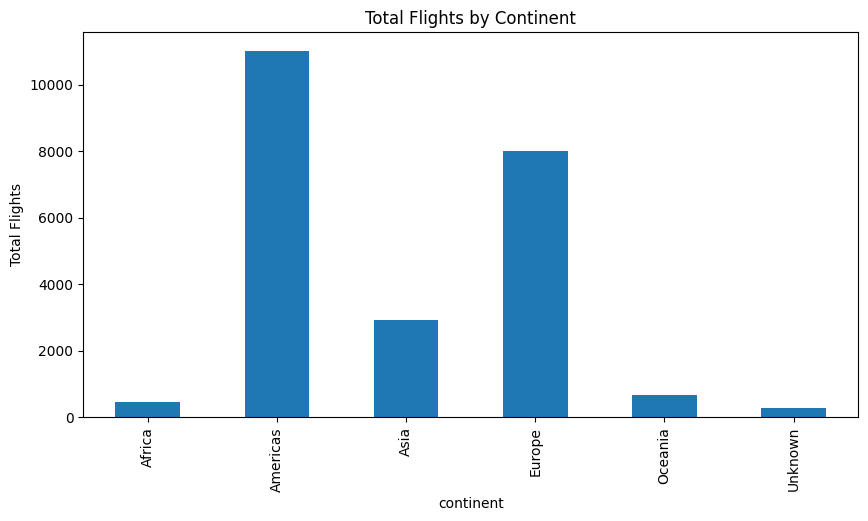

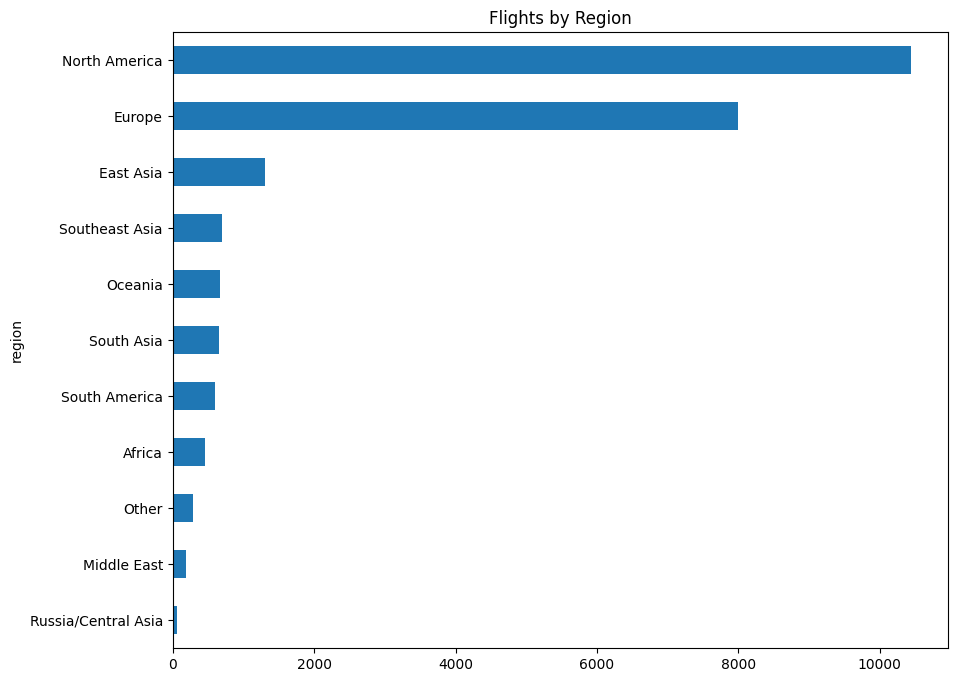

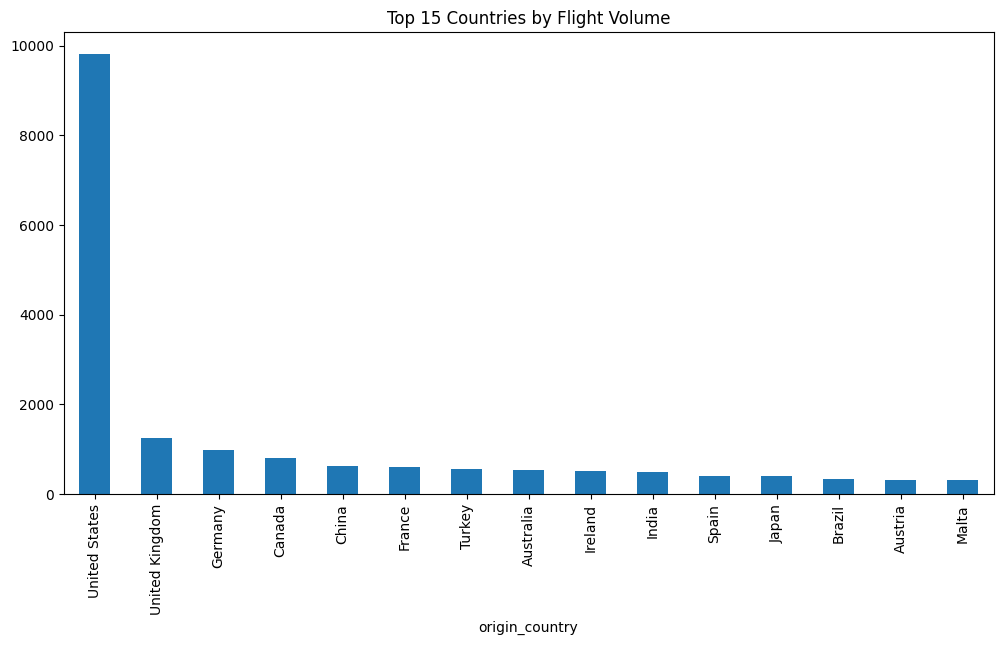

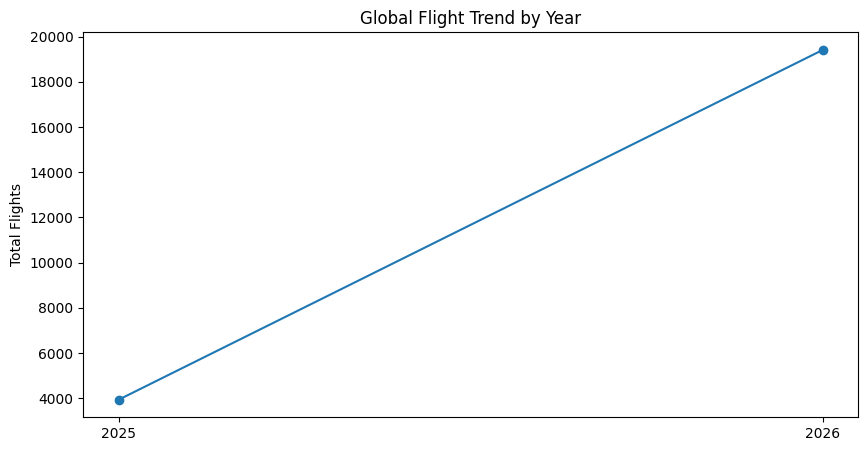

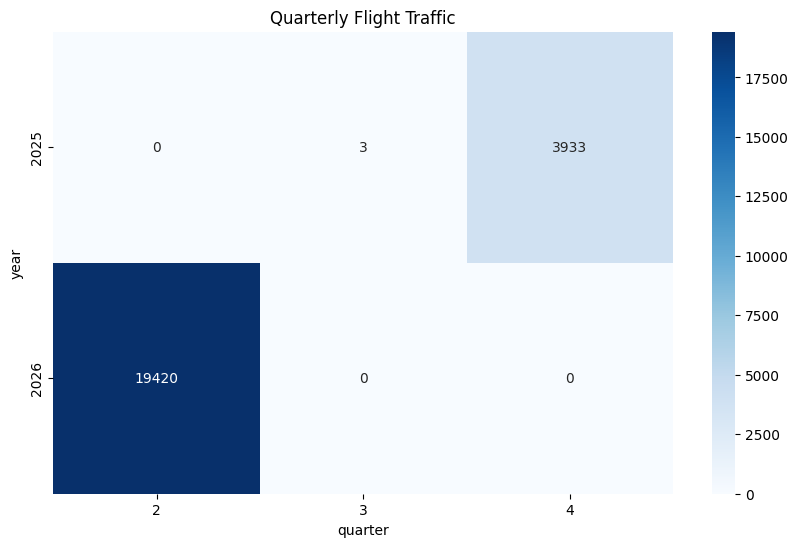

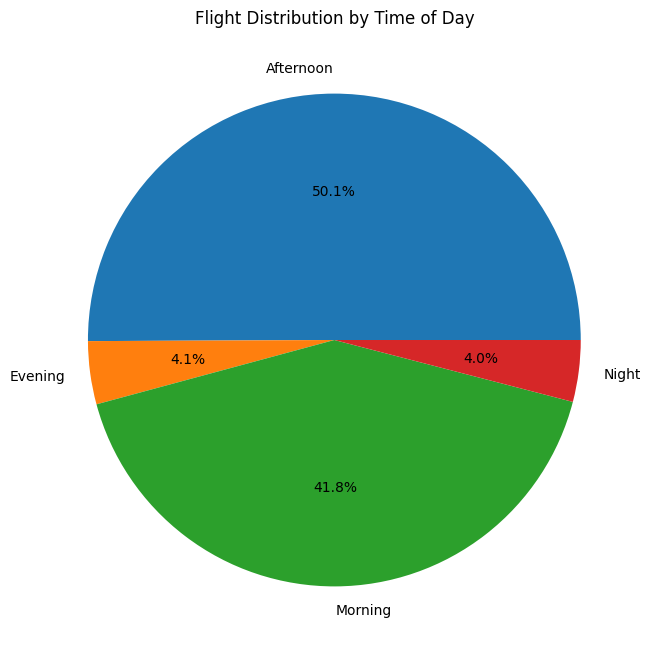

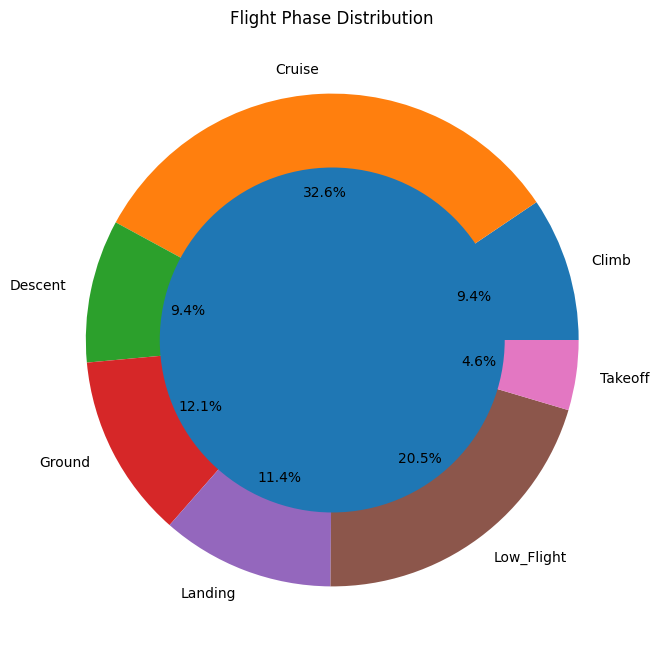

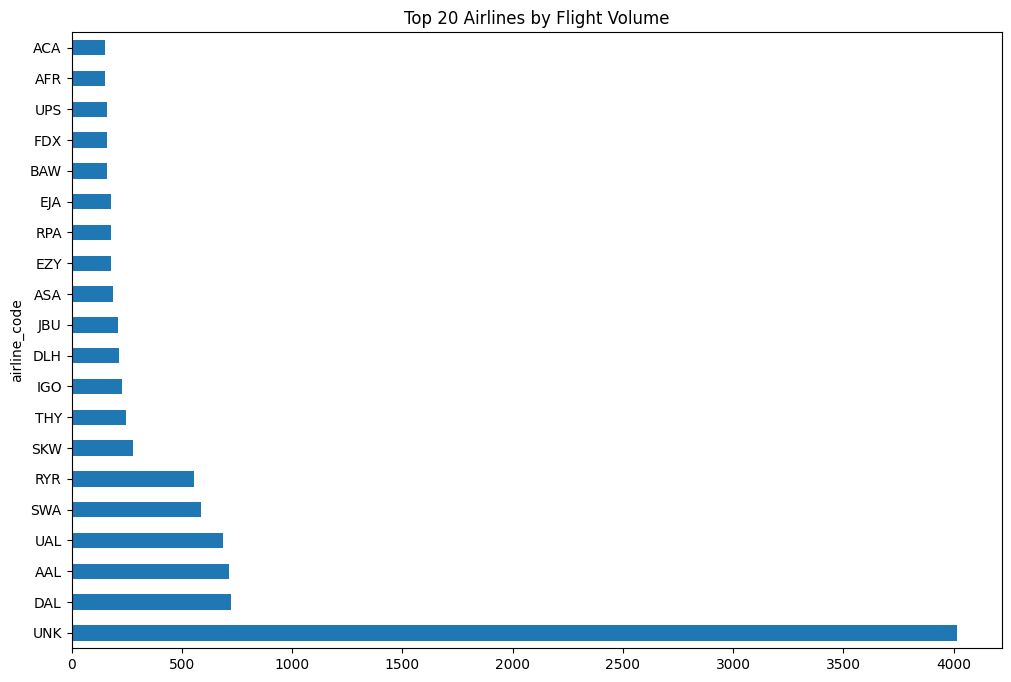

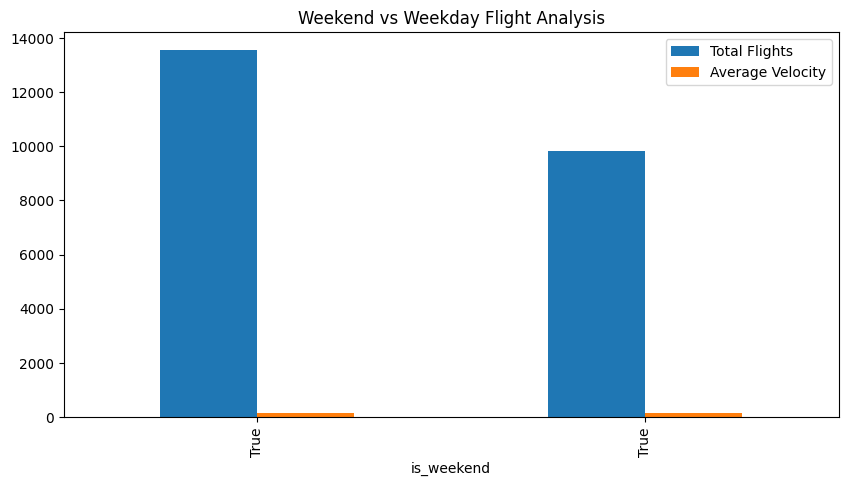

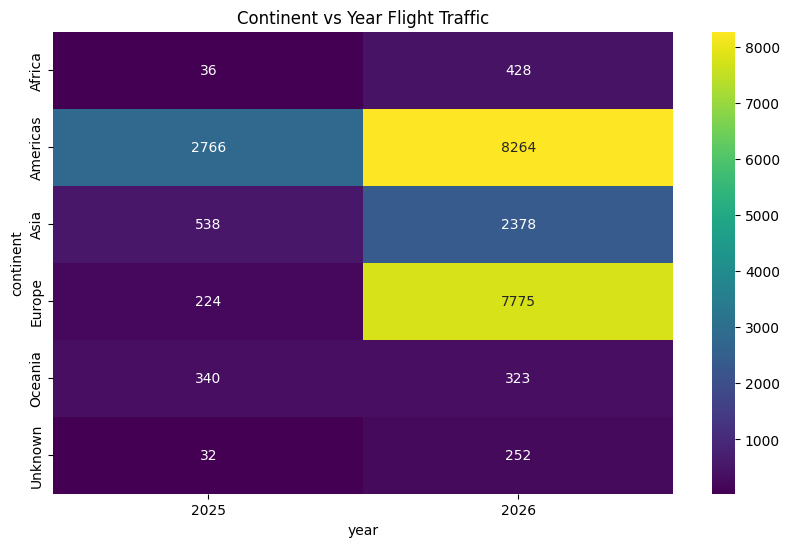

In [ ]:
# =========================================================
# VISUALISASI ROLL UP
# =========================================================
# Import Library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.figure(figsize=(10,5))

result_continent["Total Flights"].plot(kind="bar")

plt.title("Total Flights by Continent")
plt.ylabel("Total Flights")
plt.show()

plt.figure(figsize=(10,8))

result_region.sort_values(
    by="Total Flights",
    ascending=True
)["Total Flights"].plot(kind="barh")

plt.title("Flights by Region")
plt.show()

top_country = result_country.sort_values(
    by="Total Flights",
    ascending=False
).head(15)

plt.figure(figsize=(12,6))

top_country["Total Flights"].plot(kind="bar")

plt.title("Top 15 Countries by Flight Volume")
plt.show()

plt.figure(figsize=(10,5))

plt.plot(
    result_year.index.astype(str),
    result_year["Total Flights"],
    marker='o'
)

plt.title("Global Flight Trend by Year")
plt.ylabel("Total Flights")
plt.show()

quarter_heatmap = result_quarter.reset_index()

quarter_heatmap = quarter_heatmap.pivot_table(
    values="Total Flights",
    index="year",
    columns="quarter",
    aggfunc='sum'
)

quarter_heatmap = quarter_heatmap.astype(float)

quarter_heatmap = quarter_heatmap.fillna(0)

plt.figure(figsize=(10,6))

sns.heatmap(
    quarter_heatmap,
    annot=True,
    cmap='Blues',
    fmt='.0f'
)

plt.title("Quarterly Flight Traffic")
plt.show()

plt.figure(figsize=(8,8))

result_timeofday["Total Flights"].plot(
    kind="pie",
    autopct='%1.1f%%'
)

plt.title("Flight Distribution by Time of Day")
plt.ylabel("")
plt.show()

fig, ax = plt.subplots(figsize=(8,8))

ax.pie(
    result_phase["Total Flights"],
    labels=result_phase.index,
    autopct='%1.1f%%'
)

centre_circle = plt.Circle((0,0),0.70)

fig.gca().add_artist(centre_circle)

plt.title("Flight Phase Distribution")
plt.show()

top_airline = result_airline.sort_values(
    by="Total Flights",
    ascending=False
).head(20)

plt.figure(figsize=(12,8))

top_airline["Total Flights"].plot(
    kind="barh"
)

plt.title("Top 20 Airlines by Flight Volume")
plt.show()

result_weekend[
    ["Total Flights","Average Velocity"]
].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Weekend vs Weekday Flight Analysis")
plt.show()

continent_year = result_continent_year.reset_index()

continent_year = continent_year.pivot_table(
    values="Total Flights",
    index="continent",
    columns="year"
)

# convert dari pandas Int64 ke numpy float
continent_year = continent_year.astype(float)

plt.figure(figsize=(10,6))

sns.heatmap(
    continent_year,
    annot=True,
    cmap="viridis",
    fmt=".0f"
)

plt.title("Continent vs Year Flight Traffic")
plt.show()

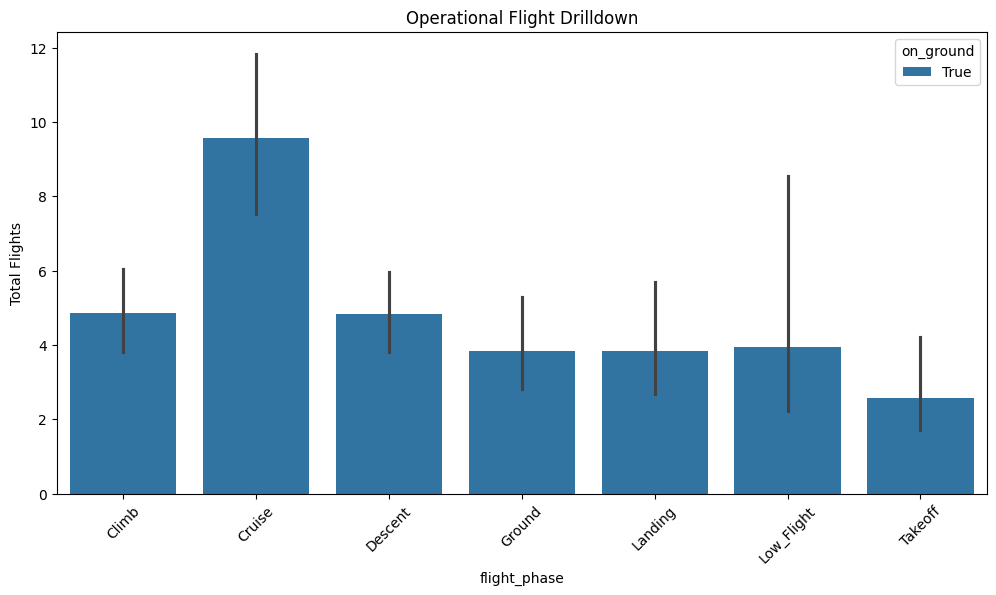

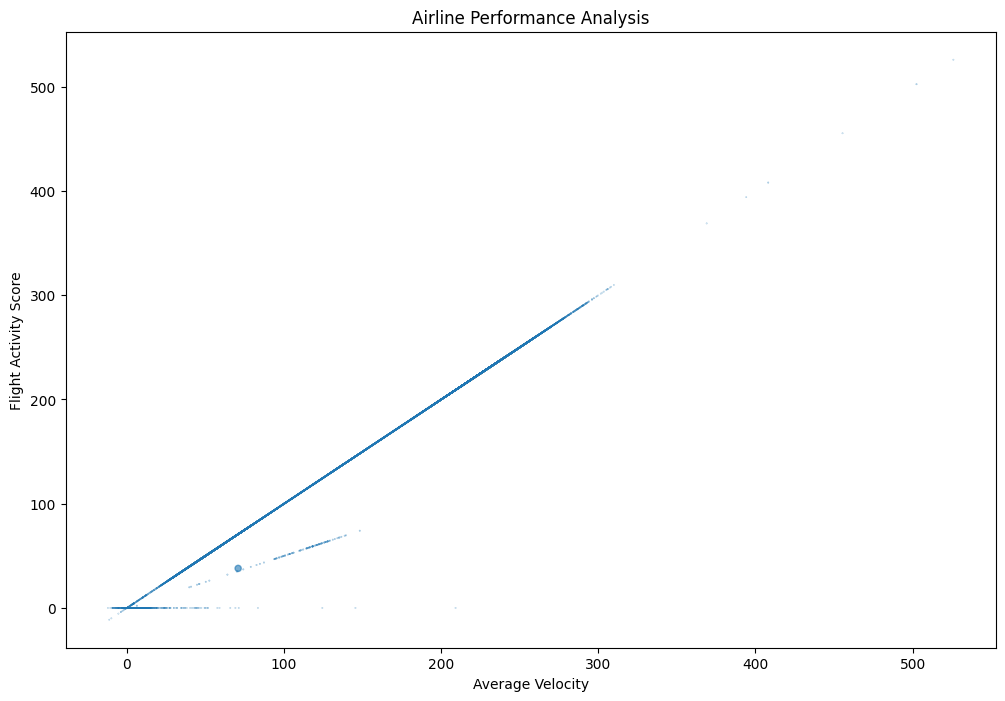

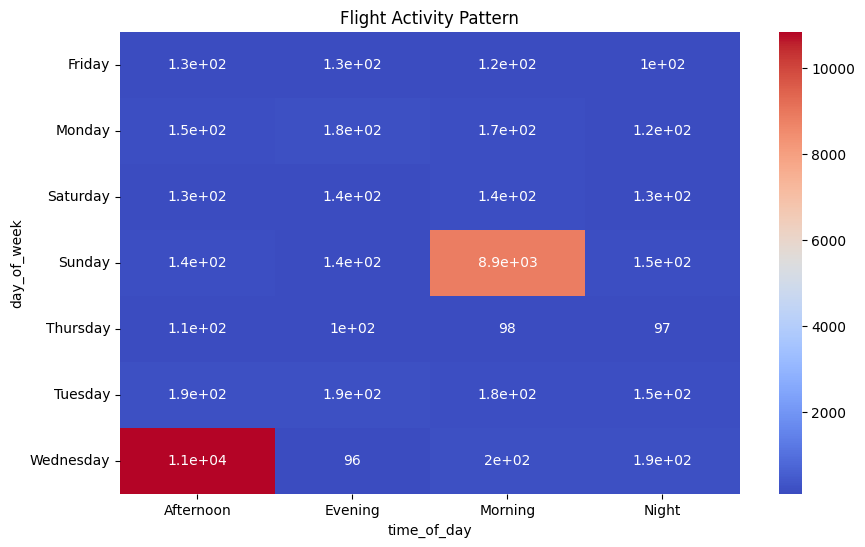

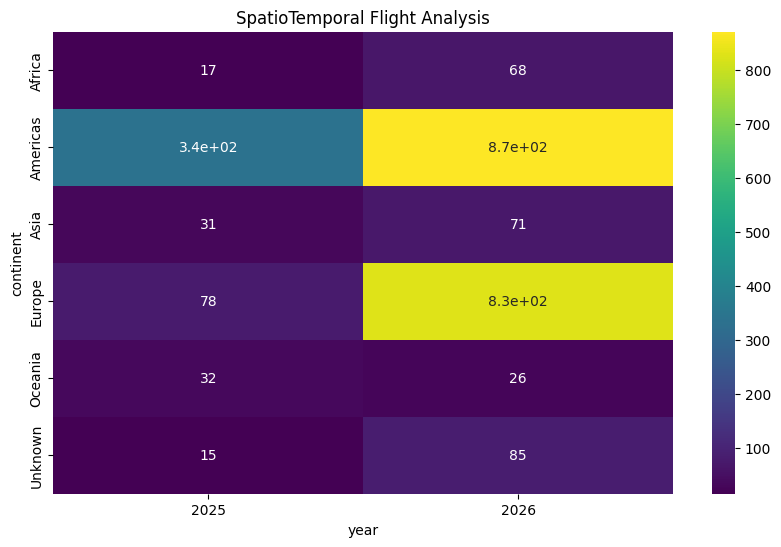

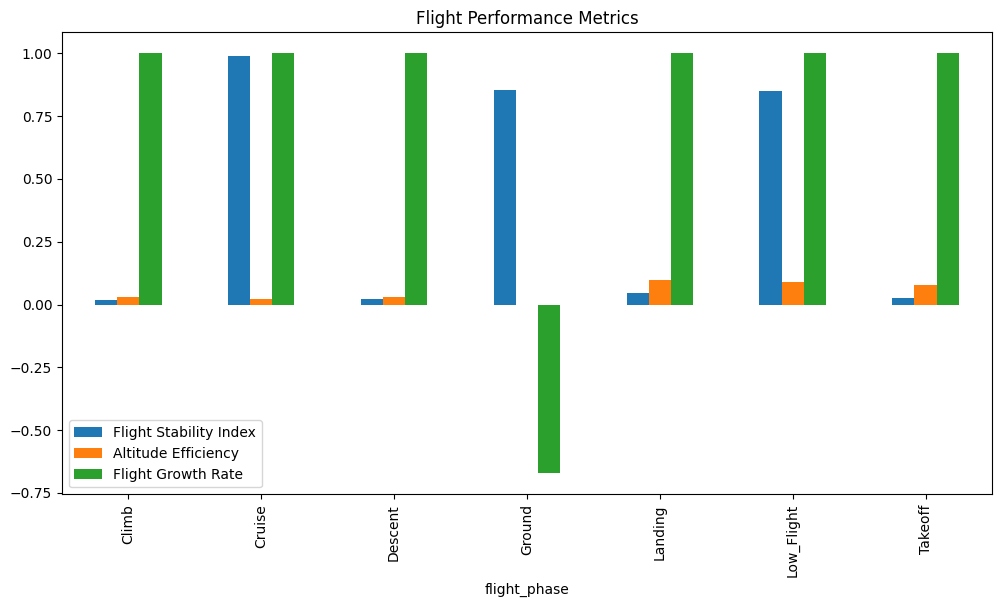

In [103]:
# =========================================================
# VISUALISASI DRILL DOWN
# =========================================================
import plotly.express as px
import plotly.io as pio

pio.renderers.default='browser'

fig = px.treemap(
    result_time_drill.reset_index(),
    path=['year','quarter','month_name','day','hour'],
    values='Total Flights',
    color='Average Velocity',
    title='Time Drilldown Flight Analysis'
)

fig.show()

fig = px.sunburst(
    result_geo_drill.reset_index(),
    path=[
        'continent',
        'region',
        'origin_country'
    ],
    values='Total Flights',
    color='Flight Activity Score',
    title='Geographic Drilldown Analysis'
)

fig.show()

flight = result_flight_drill.reset_index()

plt.figure(figsize=(12,6))

sns.barplot(
    data=flight,
    x='flight_phase',
    y='Total Flights',
    hue='on_ground'
)

plt.xticks(rotation=45)

plt.title("Operational Flight Drilldown")

plt.show()

airline = result_airline_drill.reset_index()

plt.figure(figsize=(12,8))

plt.scatter(
    airline['Average Velocity'],
    airline['Flight Activity Score'],
    s=airline['Total Flights']/20,
    alpha=0.6
)

plt.xlabel("Average Velocity")
plt.ylabel("Flight Activity Score")
plt.title("Airline Performance Analysis")

plt.show()

activity = result_activity_drill.reset_index()

activity_heatmap = activity.pivot_table(
    values='Total Flights',
    index='day_of_week',
    columns='time_of_day'
)

activity_heatmap = activity_heatmap.astype(float)

plt.figure(figsize=(10,6))

sns.heatmap(
    activity_heatmap,
    annot=True,
    cmap='coolwarm'
)

plt.title("Flight Activity Pattern")

plt.show()

spatio = result_spatiotemporal.reset_index()

spatio_map = spatio.pivot_table(
    values='Total Flights',
    index='continent',
    columns='year'
)

spatio_map = spatio_map.astype(float)

plt.figure(figsize=(10,6))

sns.heatmap(
    spatio_map,
    annot=True,
    cmap='viridis'
)

plt.title("SpatioTemporal Flight Analysis")

plt.show()

performance = result_performance.reset_index()

top_perf = performance.groupby(
    'flight_phase'
)[[
    'Flight Stability Index',
    'Altitude Efficiency',
    'Flight Growth Rate'
]].mean()

top_perf.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Flight Performance Metrics")

plt.show()



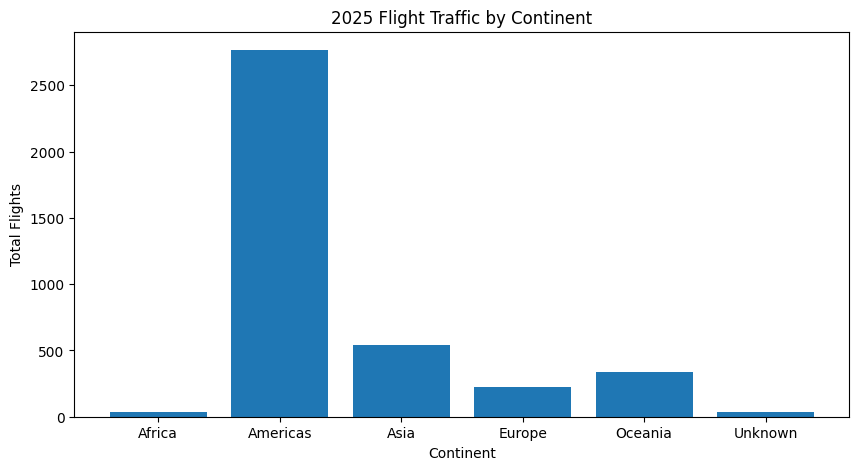

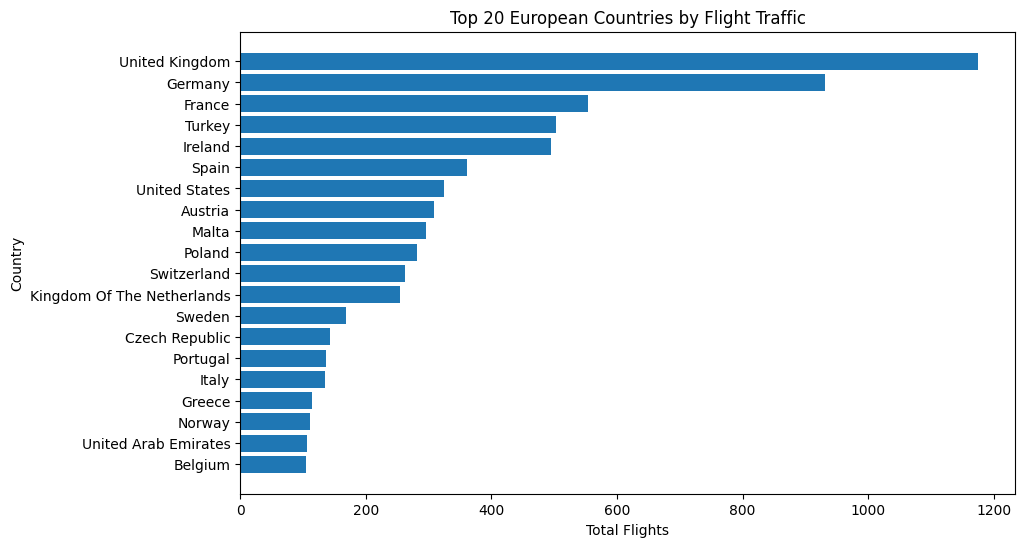

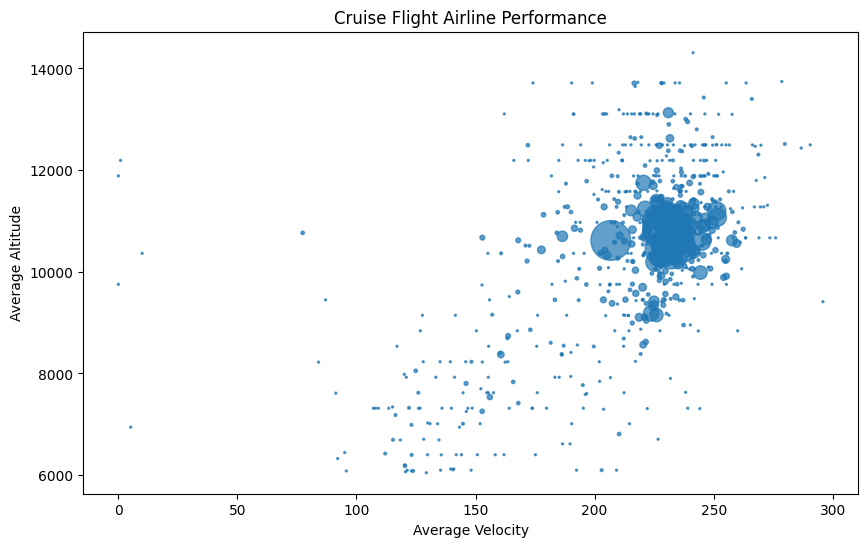

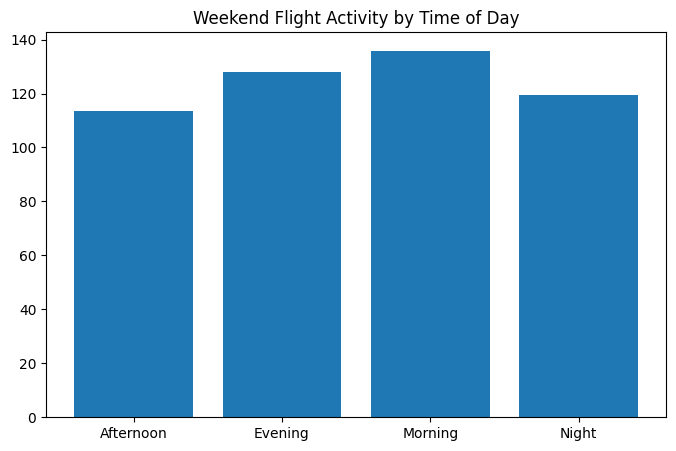

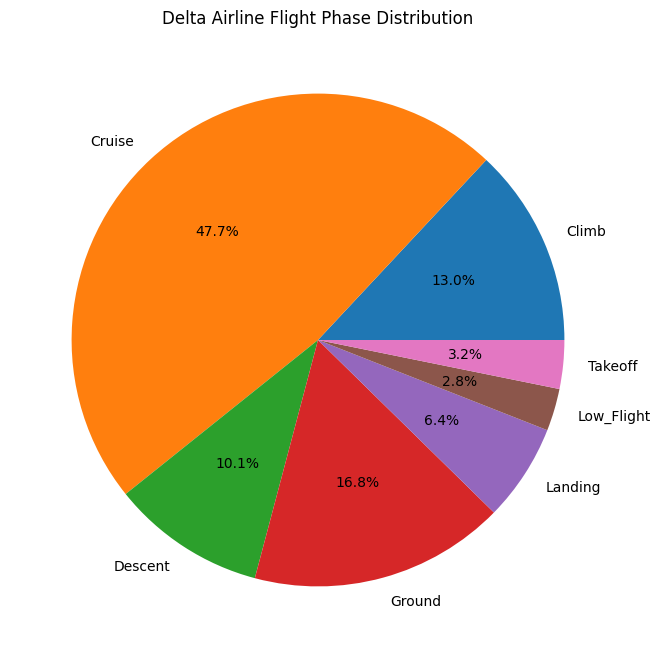

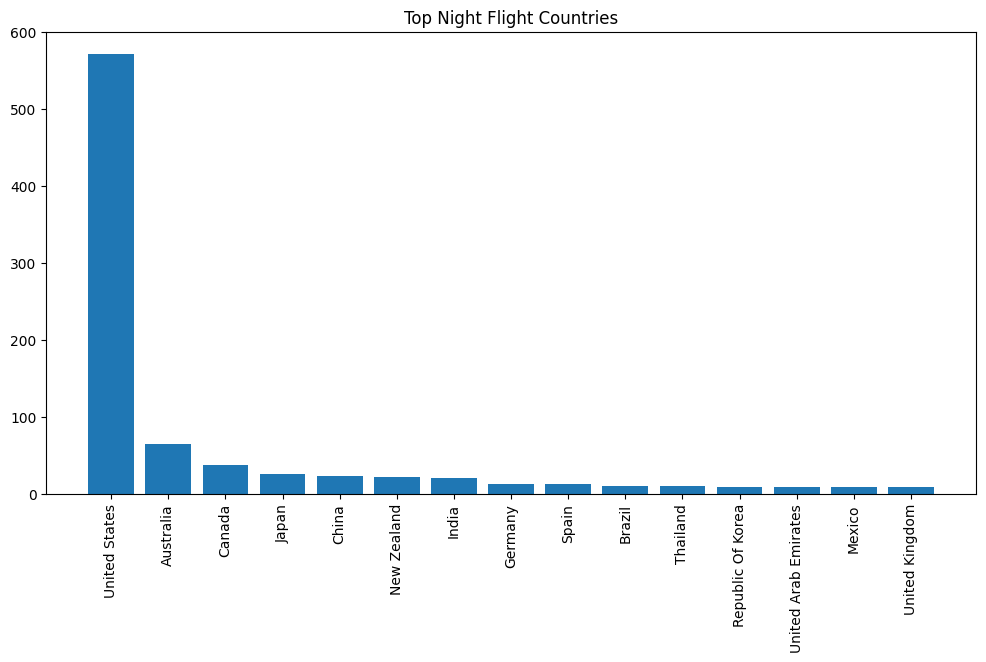

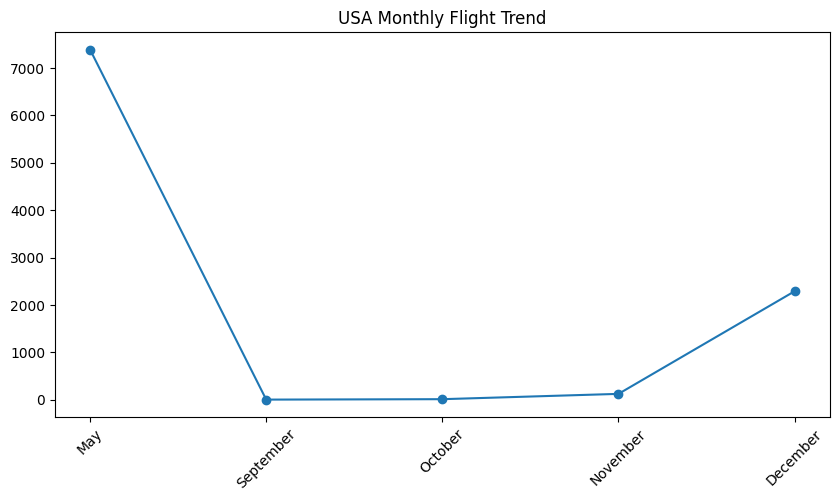

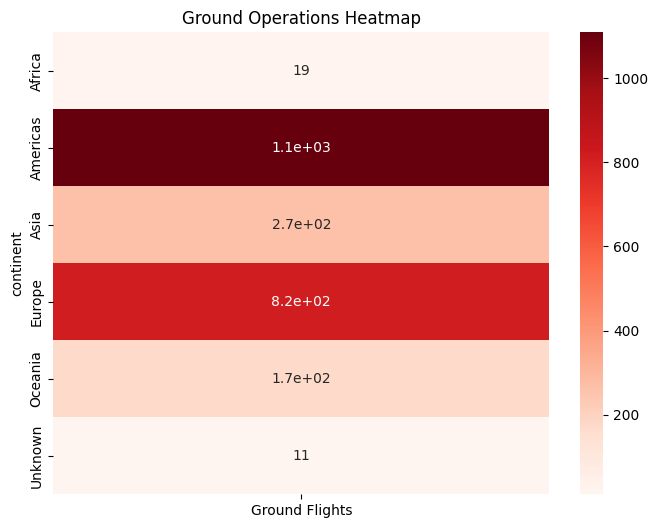

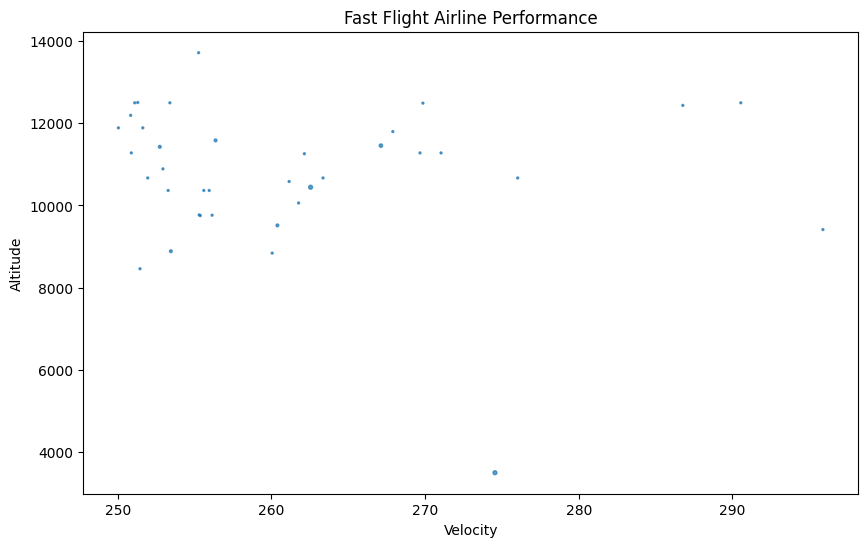

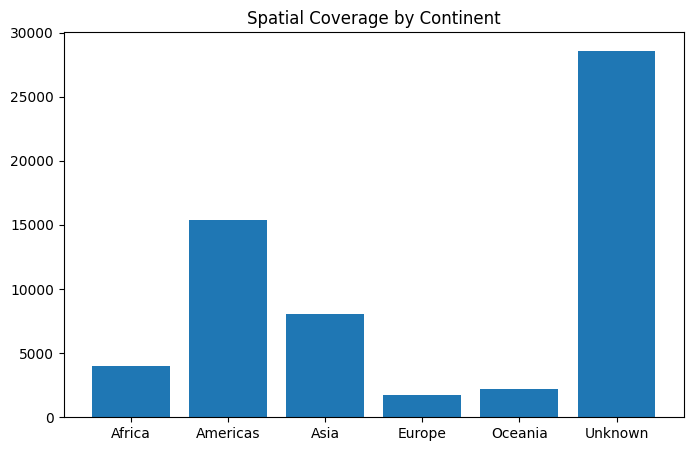

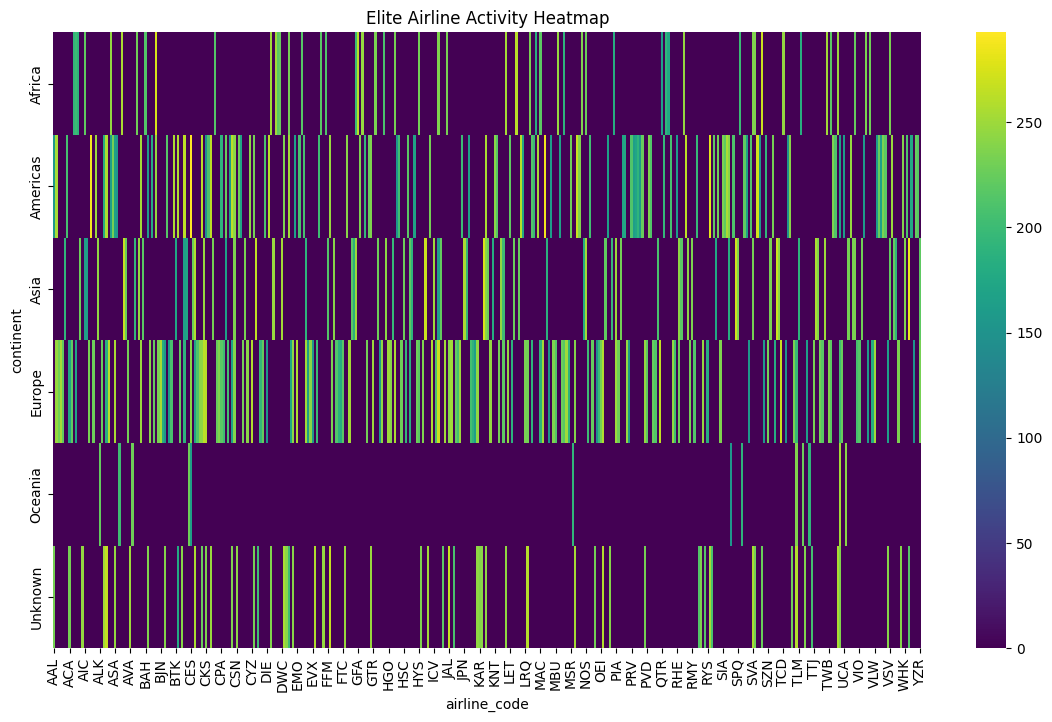

In [109]:
# =========================================================
# VISUALISASI SLICE
# =========================================================
year2025 = result_slice_year.reset_index()

plt.figure(figsize=(10,5))

plt.bar(
    year2025["continent"],
    year2025["Total Flights"]
)

plt.title("2025 Flight Traffic by Continent")
plt.xlabel("Continent")
plt.ylabel("Total Flights")

plt.show()

europe = result_slice_europe.reset_index()

# rename kalau muncul "index"
europe = europe.rename(
    columns={"index":"origin_country"}
)

# ambil TOP 10
europe = europe.sort_values(
    by="Total Flights",
    ascending=False
).head(20)

plt.figure(figsize=(10,6))

plt.barh(
    europe["origin_country"],
    europe["Total Flights"]
)

plt.xlabel("Total Flights")
plt.ylabel("Country")
plt.title("Top 20 European Countries by Flight Traffic")

plt.gca().invert_yaxis()

plt.show()
cruise = result_slice_cruise.reset_index()

plt.figure(figsize=(10,6))

plt.scatter(
    cruise["Average Velocity"],
    cruise["Average Altitude"],
    s=cruise["Total Flights"]*2,
    alpha=0.7
)

plt.xlabel("Average Velocity")
plt.ylabel("Average Altitude")
plt.title("Cruise Flight Airline Performance")

plt.show()

weekend = result_slice_weekend.reset_index()

plt.figure(figsize=(8,5))

plt.bar(
    weekend["time_of_day"],
    weekend["Flight Activity Score"]
)

plt.title("Weekend Flight Activity by Time of Day")

plt.show()

dal = result_slice_airline.reset_index()

plt.figure(figsize=(8,8))

plt.pie(
    dal["Total Flights"],
    labels=dal["flight_phase"],
    autopct='%1.1f%%'
)

plt.title("Delta Airline Flight Phase Distribution")

plt.show()

night = result_slice_night.reset_index()

night = night.sort_values(
    by="Total Flights",
    ascending=False
).head(15)

plt.figure(figsize=(12,6))

plt.bar(
    night["origin_country"],
    night["Total Flights"]
)

plt.xticks(rotation=90)

plt.title("Top Night Flight Countries")

plt.show()

usa = result_slice_usa.reset_index()

month_order = [
'January','February','March','April',
'May','June','July','August',
'September','October','November','December'
]

usa["month_name"] = pd.Categorical(
    usa["month_name"],
    categories=month_order,
    ordered=True
)

usa = usa.sort_values("month_name")

plt.figure(figsize=(10,5))

plt.plot(
    usa["month_name"],
    usa["Total Flights"],
    marker='o'
)

plt.xticks(rotation=45)

plt.title("USA Monthly Flight Trend")

plt.show()

ground = result_slice_ground.reset_index()

ground_matrix = ground.pivot_table(
    values="Ground Flights",
    index="continent"
)

ground_matrix = ground_matrix.astype(float)

plt.figure(figsize=(8,6))

sns.heatmap(
    ground_matrix,
    annot=True,
    cmap="Reds"
)

plt.title("Ground Operations Heatmap")

plt.show()

fast = result_fastflight.reset_index()

plt.figure(figsize=(10,6))

plt.scatter(
    fast["Average Velocity"],
    fast["Average Altitude"],
    s=fast["Total Flights"]*2,
    alpha=0.7
)

plt.xlabel("Velocity")
plt.ylabel("Altitude")

plt.title("Fast Flight Airline Performance")

plt.show()

spatial = result_spatial.reset_index()

plt.figure(figsize=(8,5))

plt.bar(
    spatial["continent"],
    spatial["Spatial Coverage"]
)

plt.title("Spatial Coverage by Continent")

plt.show()

elite = result_elite.reset_index()

elite_map = elite.pivot_table(
    values="Flight Activity Score",
    index="continent",
    columns="airline_code"
)

elite_map = elite_map.fillna(0).astype(float)

plt.figure(figsize=(14,8))

sns.heatmap(
    elite_map,
    cmap="viridis",
    annot=False
)

plt.title("Elite Airline Activity Heatmap")

plt.show()

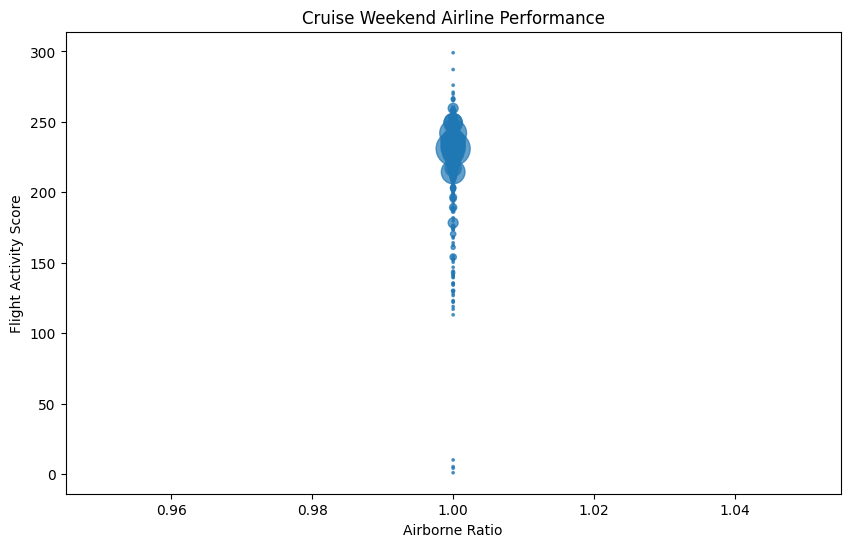

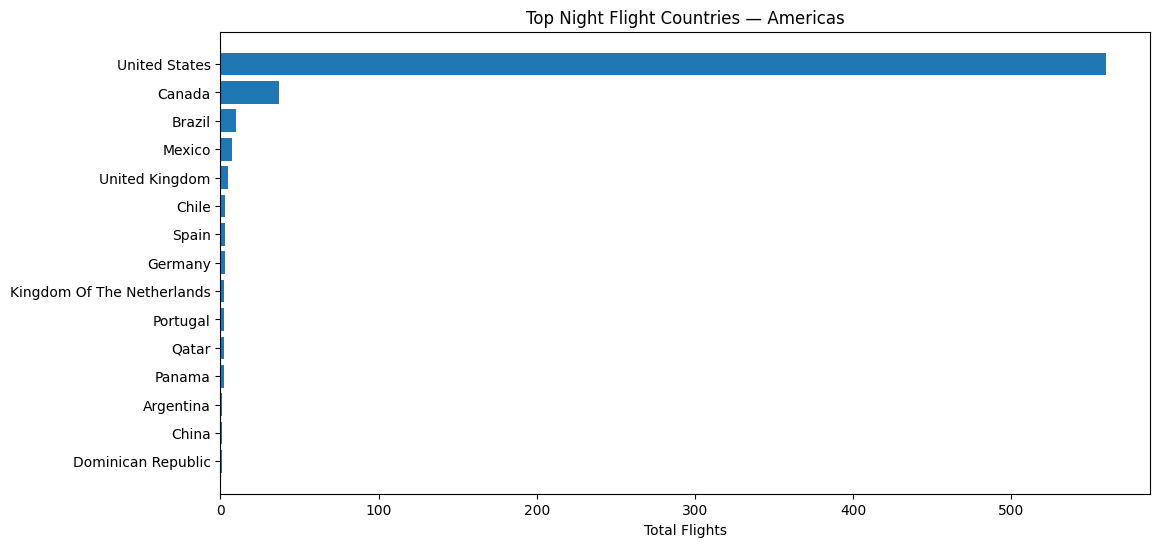

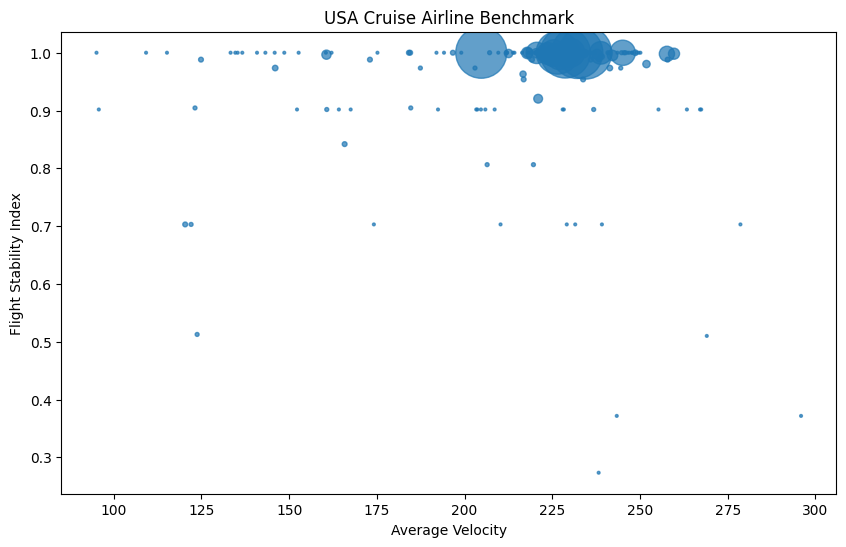

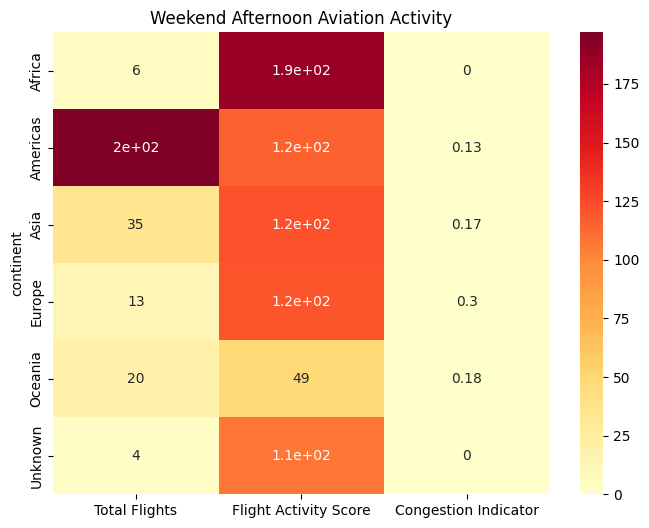

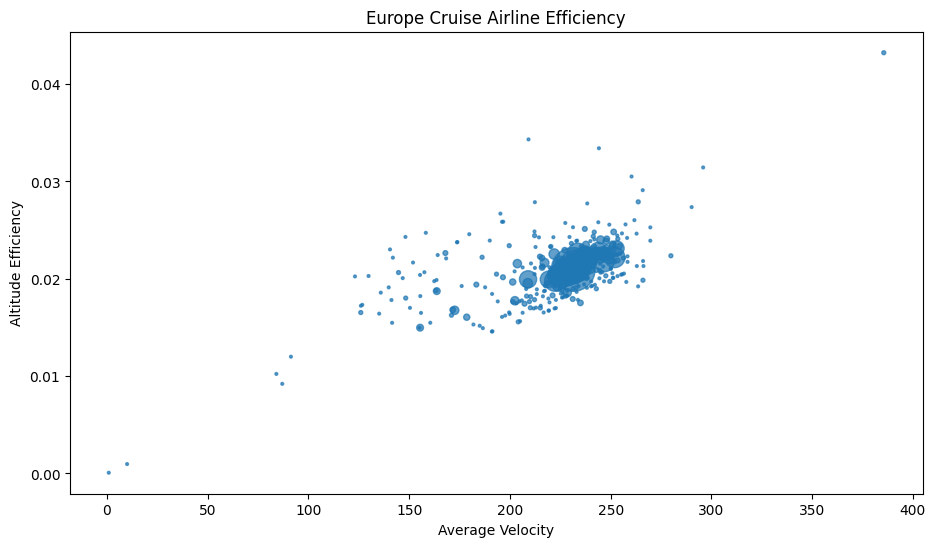

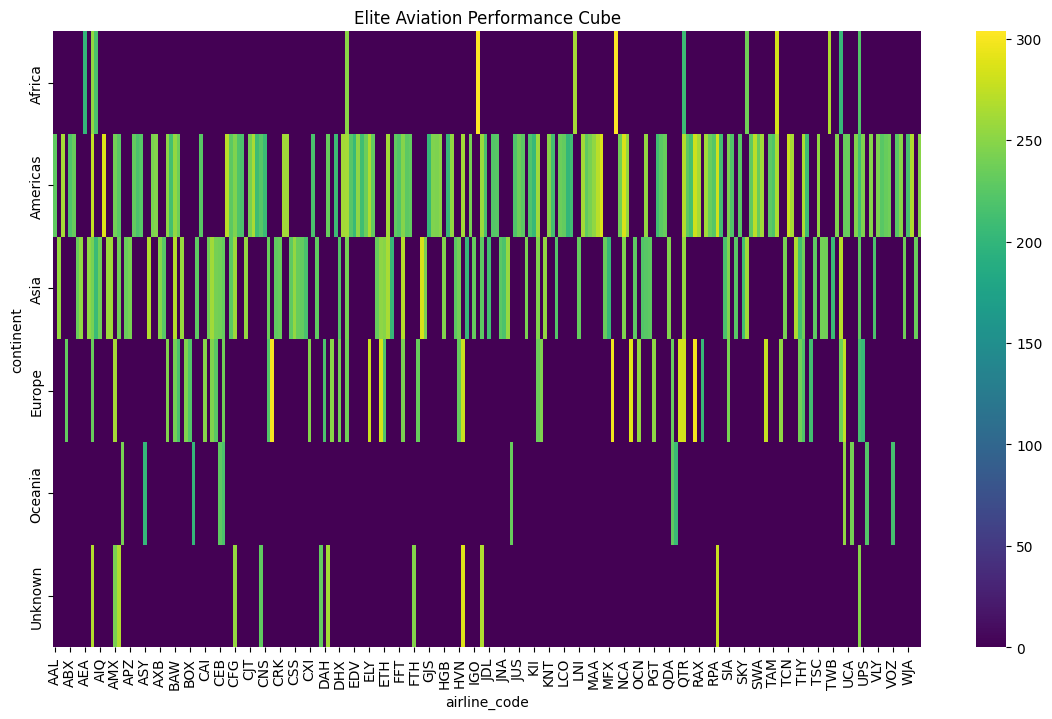

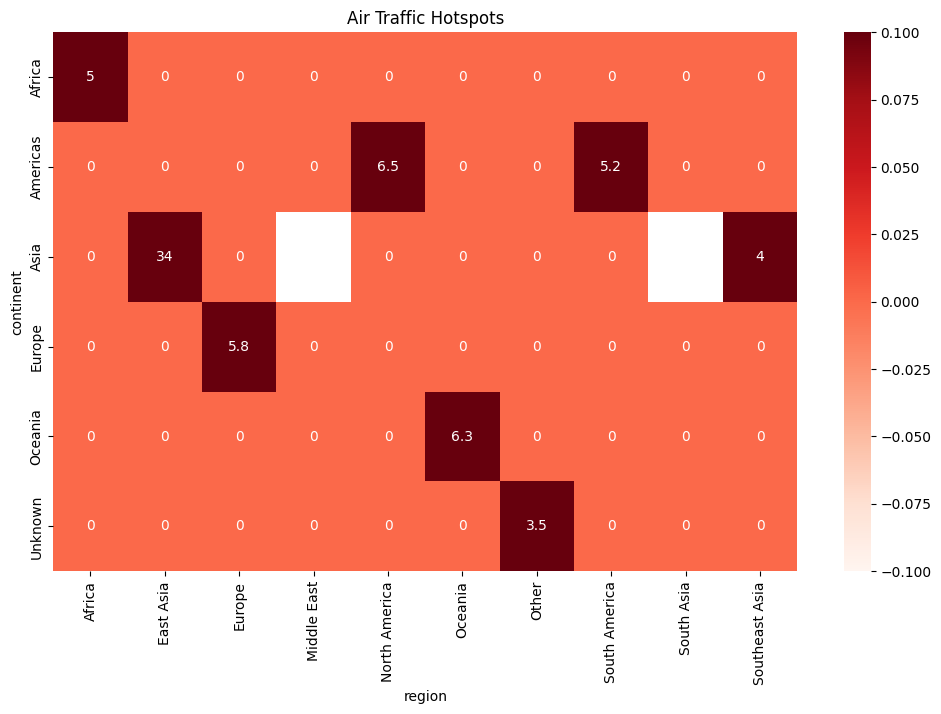

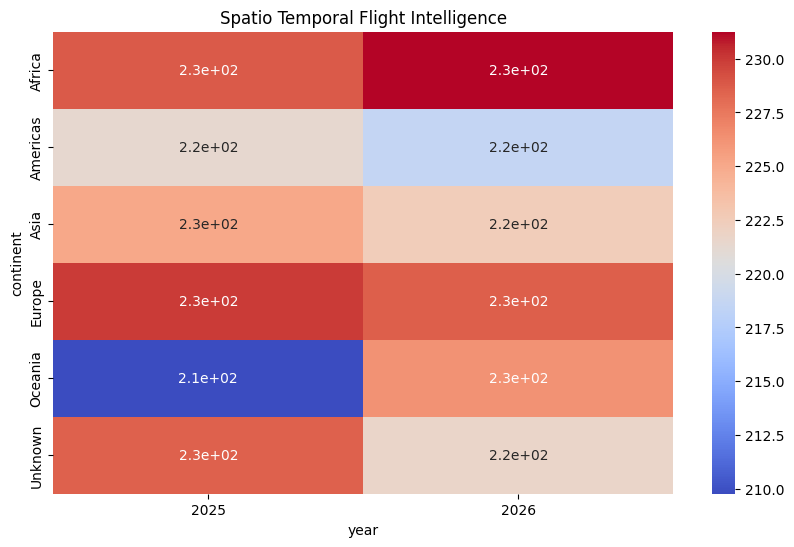

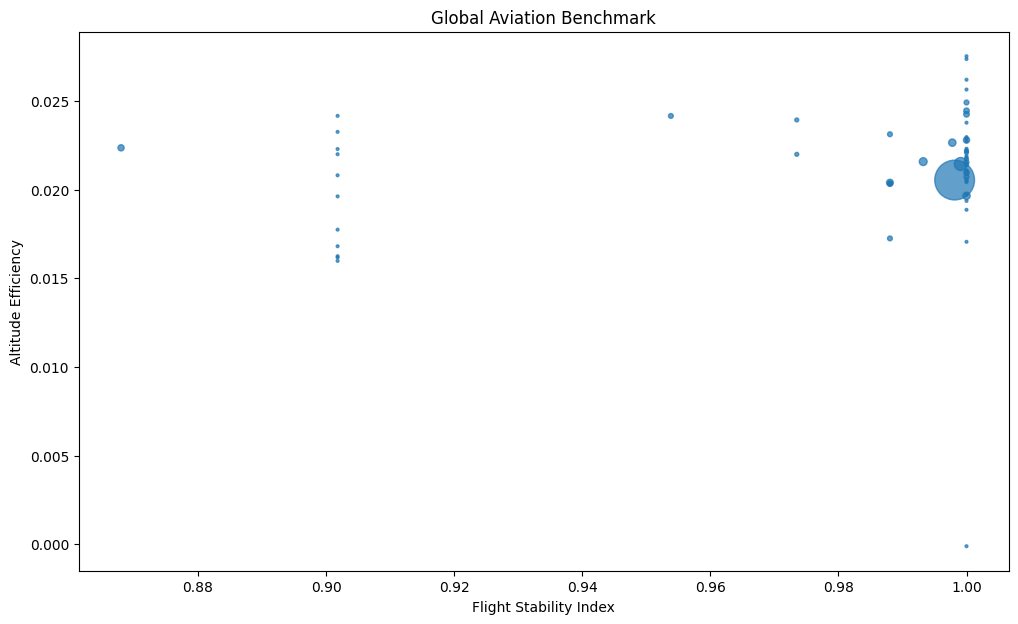

In [112]:
# =========================================================
# VISUALISASI DICE
# =========================================================
ops = result_dice_ops.reset_index()

ops = ops.rename(
    columns={"index":"airline"}
)

plt.figure(figsize=(10,6))

plt.scatter(
    ops["Airborne Ratio"],
    ops["Flight Activity Score"],
    s=ops["Total Flights"]*3,
    alpha=0.7
)

plt.xlabel("Airborne Ratio")
plt.ylabel("Flight Activity Score")

plt.title("Cruise Weekend Airline Performance")

plt.show()

geo = result_dice_geo_time.reset_index()

geo = geo.sort_values(
    by="Total Flights",
    ascending=False
).head(15)

plt.figure(figsize=(12,6))

plt.barh(
    geo["origin_country"],
    geo["Total Flights"]
)

plt.gca().invert_yaxis()

plt.title("Top Night Flight Countries — Americas")
plt.xlabel("Total Flights")
plt.show()

usa = result_dice_country_airline.reset_index()

usa = usa.rename(
    columns={"index":"airline"}
)

plt.figure(figsize=(10,6))

plt.scatter(
    usa["Average Velocity"],
    usa["Flight Stability Index"],
    s=usa["Total Flights"]*4,
    alpha=0.7
)

plt.xlabel("Average Velocity")
plt.ylabel("Flight Stability Index")

plt.title("USA Cruise Airline Benchmark")

plt.show()

activity = result_dice_activity.reset_index()

activity = activity.rename(
    columns={"index":"continent"}
)

heat = activity.set_index(
    "continent"
)[["Total Flights","Flight Activity Score","Congestion Indicator"]]

heat = heat.astype(float)

plt.figure(figsize=(8,6))

sns.heatmap(
    heat,
    annot=True,
    cmap="YlOrRd"
)

plt.title("Weekend Afternoon Aviation Activity")

plt.show()

geoair = result_dice_airline_geo.reset_index()

geoair = geoair.rename(
    columns={"index":"airline"}
)

plt.figure(figsize=(11,6))

plt.scatter(
    geoair["Average Velocity"],
    geoair["Altitude Efficiency"],
    s=geoair["Total Flights"]*4,
    alpha=0.7
)

plt.xlabel("Average Velocity")
plt.ylabel("Altitude Efficiency")

plt.title("Europe Cruise Airline Efficiency")

plt.show()

elite = result_elite_cube.reset_index()

elite = elite.rename(
    columns={
        "index":"continent"
    }
)

elite_map = elite.pivot_table(
    values="Flight Activity Score",
    index="continent",
    columns="airline_code"
)

elite_map = elite_map.fillna(0).astype(float)

plt.figure(figsize=(14,8))

sns.heatmap(
    elite_map,
    cmap="viridis"
)

plt.title("Elite Aviation Performance Cube")

plt.show()

hotspot = result_hotspot.reset_index()

hotspot.columns = [
'continent',
'region',
'Total Flights',
'Regional Traffic Share',
'Congestion Indicator'
]

pivot_hotspot = hotspot.pivot_table(
    values="Congestion Indicator",
    index="continent",
    columns="region"
)

pivot_hotspot = pivot_hotspot.fillna(0).astype(float)

plt.figure(figsize=(12,7))

sns.heatmap(
    pivot_hotspot,
    annot=True,
    cmap="Reds"
)

plt.title("Air Traffic Hotspots")

plt.show()

spatio = result_spatiotemporal.reset_index()

spatio.columns = [
'year',
'continent',
'region',
'Total Flights',
'Average Velocity',
'Flight Activity Score',
'Spatial Coverage'
]

heat = spatio.pivot_table(
    values="Flight Activity Score",
    index="continent",
    columns="year"
)

heat = heat.fillna(0).astype(float)

plt.figure(figsize=(10,6))

sns.heatmap(
    heat,
    annot=True,
    cmap="coolwarm"
)

plt.title("Spatio Temporal Flight Intelligence")

plt.show()

bench = result_benchmark.reset_index()

bench.columns = [
'continent',
'country',
'Total Flights',
'Flight Stability Index',
'Altitude Efficiency',
'Active Airline Ratio',
'Flight Growth Rate'
]

plt.figure(figsize=(12,7))

plt.scatter(
    bench["Flight Stability Index"],
    bench["Altitude Efficiency"],
    s=bench["Total Flights"]*4,
    alpha=0.7
)

plt.xlabel("Flight Stability Index")
plt.ylabel("Altitude Efficiency")

plt.title("Global Aviation Benchmark")

plt.show()




Total Flights : 23356
Average Altitude : 5258.82


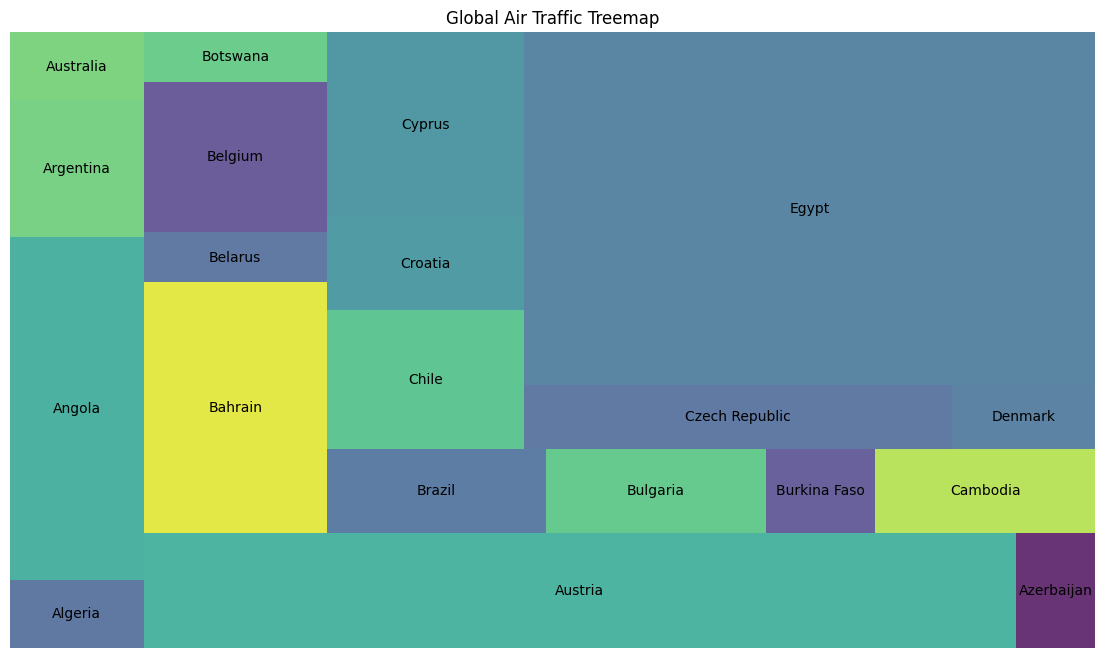

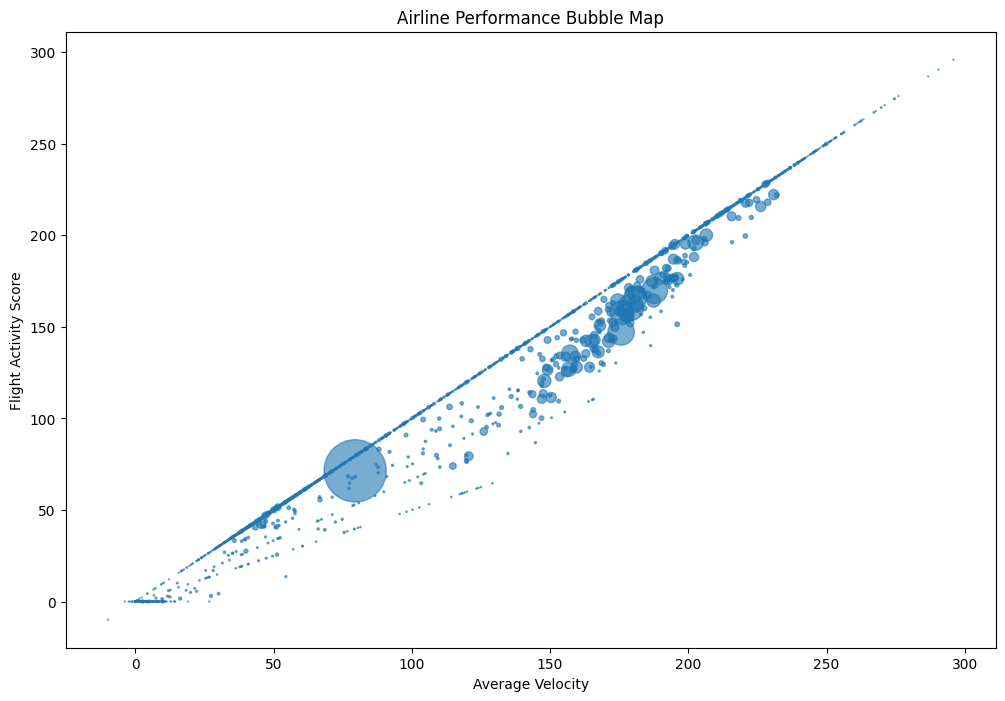

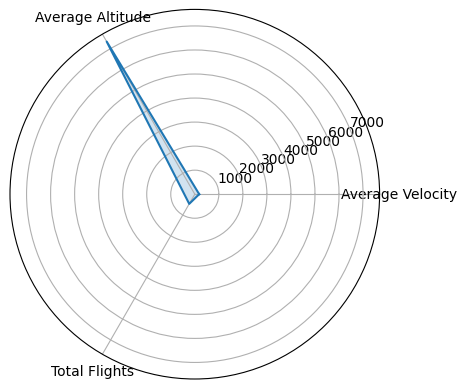

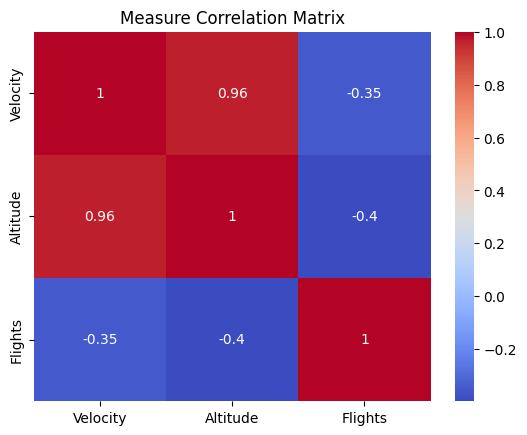

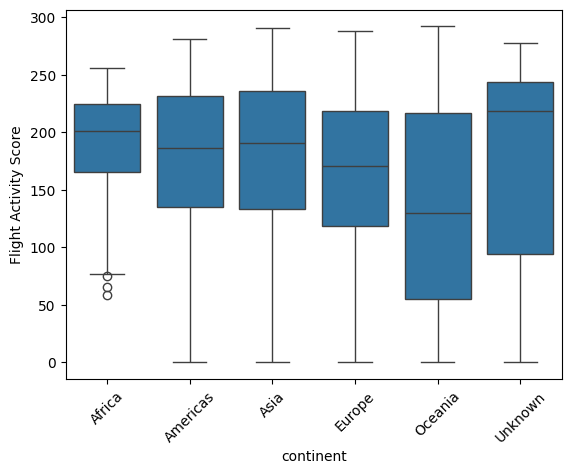

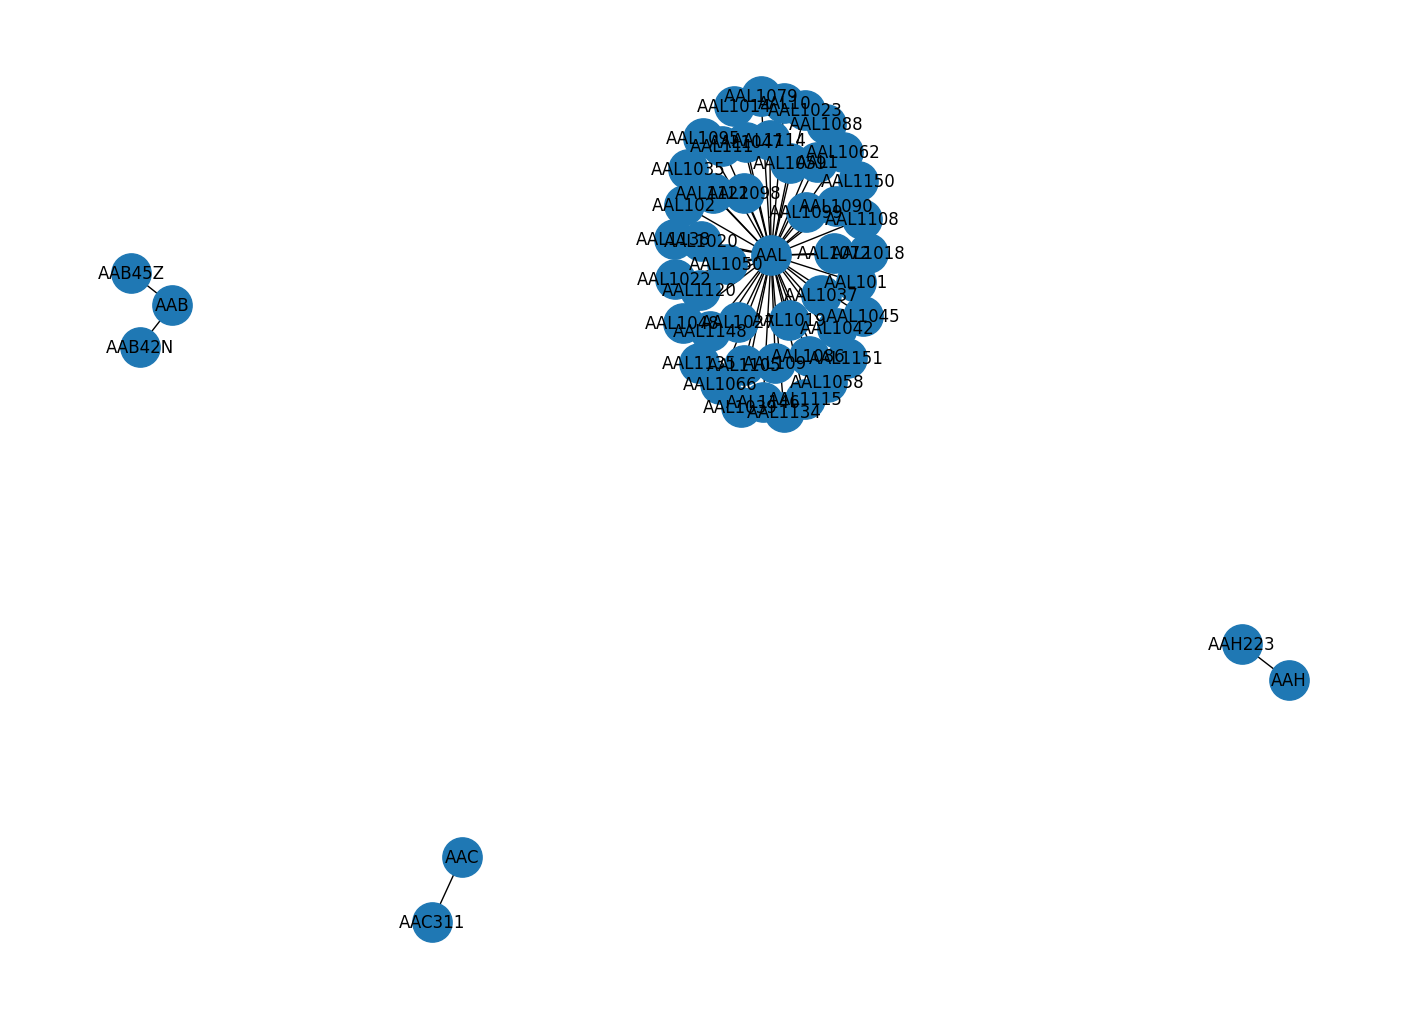

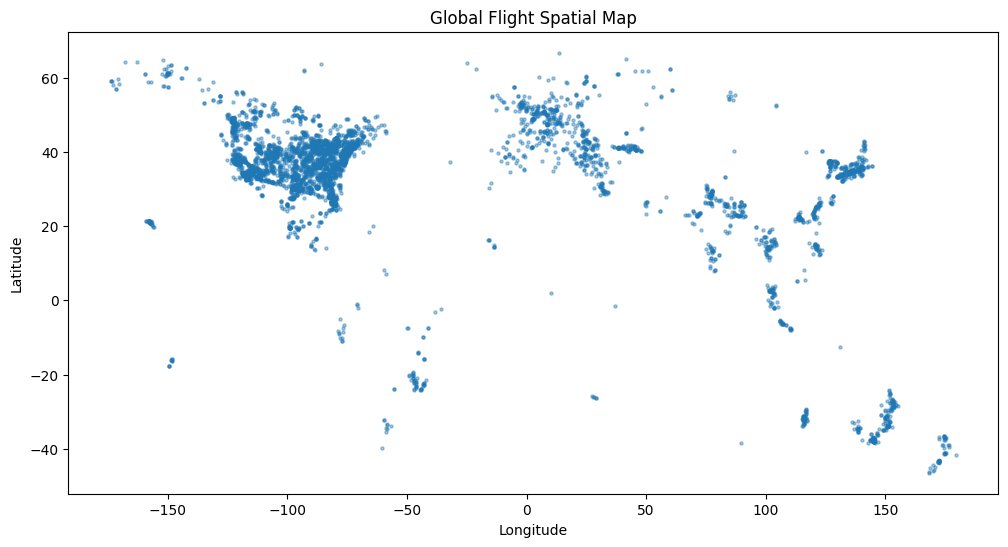

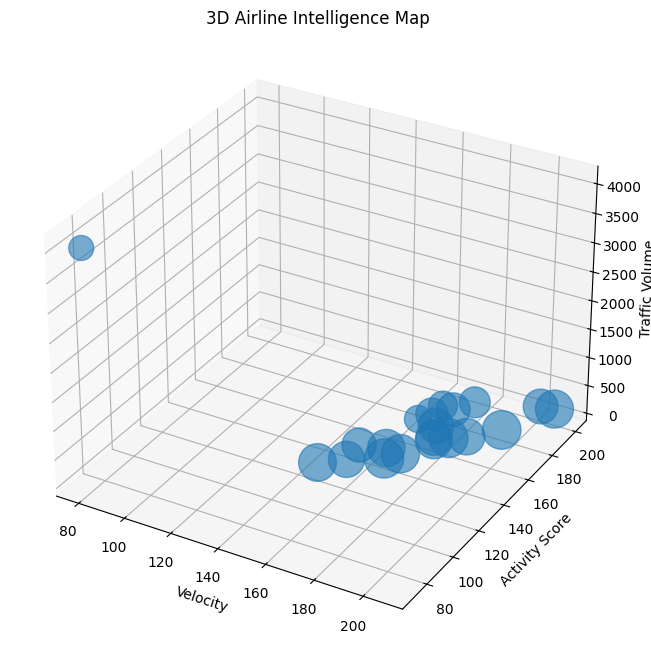

In [120]:
print("Total Flights :", result_year["Total Flights"].sum())
print("Average Altitude :", round(result_year["Average Altitude"].mean(),2))

import squarify

geo = result_geo.reset_index()

sizes = geo["Total Flights"].head(20)

labels = geo["origin_country"].head(20)

plt.figure(figsize=(14,8))

squarify.plot(
    sizes=sizes,
    label=labels,
    alpha=0.8
)

plt.axis('off')
plt.title("Global Air Traffic Treemap")
plt.show()

air = result_airline.reset_index()

plt.figure(figsize=(12,8))

plt.scatter(
    air["Average Velocity"],
    air["Flight Activity Score"],
    s=air["Total Flights"]/2,
    alpha=0.6
)

plt.xlabel("Average Velocity")
plt.ylabel("Flight Activity Score")

plt.title("Airline Performance Bubble Map")

plt.show()

from math import pi

radar = result_continent.reset_index()

categories = [
'Average Velocity',
'Average Altitude',
'Total Flights'
]

values = radar.iloc[0][categories].tolist()

values += values[:1]

angles = [n/float(len(categories))*2*pi for n in range(len(categories))]
angles += angles[:1]

ax = plt.subplot(111, polar=True)

plt.xticks(angles[:-1], categories)

ax.plot(angles, values)

plt.fill(angles, values, alpha=0.2)

plt.show()

corr_data = pd.DataFrame({

'Velocity':result_continent["Average Velocity"],

'Altitude':result_continent["Average Altitude"],

'Flights':result_continent["Total Flights"]

})

sns.heatmap(
    corr_data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Measure Correlation Matrix")
plt.show()

air = result_airline.reset_index()

air = air.sort_values(
    by='Total Flights',
    ascending=False
).head(20)

air['cumperc'] = (
    air['Total Flights'].cumsum()
    /air['Total Flights'].sum()
)*100

geo = result_geo_drill.reset_index()

sns.boxplot(
    x="continent",
    y="Flight Activity Score",
    data=geo
)

plt.xticks(rotation=45)

plt.show()

import networkx as nx

G = nx.Graph()

sample = result_airline_drill.reset_index().head(50)

for _,row in sample.iterrows():

    G.add_edge(
        row['airline_code'],
        row['callsign']
    )

plt.figure(figsize=(14,10))

nx.draw(
    G,
    with_labels=True,
    node_size=800
)

plt.show()

spatial = df.sample(5000)

plt.figure(figsize=(12,6))

plt.scatter(

spatial['longitude'],

spatial['latitude'],

alpha=0.4,

s=5

)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title("Global Flight Spatial Map")

plt.show()

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(
    111,
    projection='3d'
)

ax.scatter(

    air["Average Velocity"],

    air["Flight Activity Score"],

    air["Total Flights"],

    s=air["cumperc"]*8,

    alpha=0.6
)

ax.set_xlabel("Velocity")
ax.set_ylabel("Activity Score")
ax.set_zlabel("Traffic Volume")

plt.title("3D Airline Intelligence Map")

plt.show()